In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit, least_squares
#import statsmodels.formula.api as smf
#from scipy.optimize import OptimizeWarning
#import warnings
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import chi2
from scipy.stats import norm
import importlib
import meine_Funktionen
importlib.reload(meine_Funktionen)


In [ ]:
# Gaußfunktion
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Daten vorbereiten 

In [ ]:
try:
    daten421_10 = meine_Funktionen.load_data('FACT_preliminary_Mrk421_10min_100101_241231_CutsLC_internal.dat')
    daten421_20 = meine_Funktionen.load_data('FACT_preliminary_Mrk421_20min_100101_241231_CutsLC_internal.dat')
    daten421_30 = meine_Funktionen.load_data('FACT_preliminary_Mrk421_30min_100101_241231_CutsLC_internal.dat')
    daten421_40 = meine_Funktionen.load_data('FACT_preliminary_Mrk421_40min_100101_241231_CutsLC_internal.dat')
    daten421_60 = meine_Funktionen.load_data('FACT_preliminary_Mrk421_60min_100101_241231_CutsLC_internal.dat')
    daten421_n = meine_Funktionen.load_data('FACT_preliminary_Mrk421_nightly_100101_241231_CutsLC_internal.dat')
except:
    pass

In [ ]:
daten421_10 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_20 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_30 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_40 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_60 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_n = meine_Funktionen.load_data('FACT_preliminary_421_nightly_150101_191231_katha.dat')


In [ ]:
daten421_10

In [ ]:
daten_421_20_gruppiert=meine_Funktionen.gruppiere_datenpunkte(daten421_20, 0.5, "MJD")

daten_421_20_gruppiert = {
    gruppe: daten
    for gruppe, daten in daten_421_20_gruppiert.groupby("Gruppe")
}

In [ ]:
daten_421_10_gruppiert=meine_Funktionen.gruppiere_datenpunkte(daten421_10, 0.5, "MJD")

daten_421_10_gruppiert = {
    gruppe: daten
    for gruppe, daten in daten_421_10_gruppiert.groupby("Gruppe")
}

In [ ]:
daten_421_30_gruppiert=meine_Funktionen.gruppiere_datenpunkte(daten421_30, 0.5, "MJD")

daten_421_30_gruppiert = {
    gruppe: daten
    for gruppe, daten in daten_421_30_gruppiert.groupby("Gruppe")
}

In [ ]:
daten_421_40_gruppiert=meine_Funktionen.gruppiere_datenpunkte(daten421_40, 0.5, "MJD")

daten_421_40_gruppiert = {
    gruppe: daten
    for gruppe, daten in daten_421_40_gruppiert.groupby("Gruppe")
}

In [ ]:
daten_421_60_gruppiert=meine_Funktionen.gruppiere_datenpunkte(daten421_60, 0.5, "MJD")

daten_421_60_gruppiert = {
    gruppe: daten
    for gruppe, daten in daten_421_60_gruppiert.groupby("Gruppe")
}

### Daten verarbeiten

In [ ]:
if __name__ == "__main__":
    df_results_10 = meine_Funktionen.process_all_groups_parallel(
        daten_421_10_gruppiert
    )
    df_results_20 = meine_Funktionen.process_all_groups_parallel(
        daten_421_20_gruppiert
    )
    df_results_30 = meine_Funktionen.process_all_groups_parallel(
        daten_421_30_gruppiert
    )
    df_results_40 = meine_Funktionen.process_all_groups_parallel(
        daten_421_40_gruppiert
    )
    df_results_60 = meine_Funktionen.process_all_groups_parallel(
        daten_421_60_gruppiert
    )

### Daten plotten und speichern 

In [ ]:
df_results_60

In [ ]:
df_results_60.classification.value_counts()

In [ ]:
df_results_60.loc[~df_results_60["classification"].isin(["konstant/rauschen (Model)","zu wenige daten"])].gruppe.unique()


In [ ]:
if __name__ == "__main__":
    meine_Funktionen.create_group_plots_pdf_parallel(df_results_10, "alle_gruppen_plots_10.pdf")

In [ ]:
#if __name__ == "__main__":
#    meine_Funktionen.create_group_plots_pdf_parallel(df_results_20, "alle_gruppen_plots_20.pdf")

In [ ]:
#if __name__ == "__main__":
#    meine_Funktionen.create_group_plots_pdf_parallel(df_results_30, "alle_gruppen_plots_30.pdf")

In [ ]:
#if __name__ == "__main__":
#    meine_Funktionen.create_group_plots_pdf_parallel(df_results_40, "alle_gruppen_plots_40.pdf")

In [ ]:
#if __name__ == "__main__":
#    meine_Funktionen.create_group_plots_pdf_parallel(df_results_60, "alle_gruppen_plots_60.pdf")

# Daten verarbeiten

In [ ]:
daten421_n = daten421_n.sort_values("MJD").reset_index(drop=True)


### nightly daten subtrahieren (n-(n-1))

In [ ]:
sub_nach = daten421_n["CU"] - daten421_n["CU"].shift(-1)

In [ ]:
sub_nach_err = np.sqrt((daten421_n["CU_err"])**2 + (daten421_n["CU_err"].shift(-1))**2)


In [ ]:
print(max(sub_nach))
print(min(sub_nach))
print(20*(max(sub_nach)-min(sub_nach)))

In [ ]:
number_bins=130

In [ ]:
sub_nach = sub_nach.dropna()
sub_nach_err = sub_nach_err.dropna()

In [ ]:
sub_nach.hist(bins=number_bins)
plt.xlabel("Flux difference [CU]")
#plt.ylabel("number")
plt.title("Histogram for substraction of n-1 from n")
plt.show()

In [ ]:
# Histogramm erzeugen
counts, bins = np.histogram(sub_nach, bins=number_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Startwerte
p0 = [max(counts), np.mean(sub_nach), np.std(sub_nach)]

# Fit
popt, pcov = curve_fit(gauss, bin_centers, counts, p0=p0)

A, mu, sigma = popt
perr = np.sqrt(np.diag(pcov))
dA, dmu, dsigma = perr

print(f"A = {A:.5f} ± {dA:.5f}")
print(f"mu = {mu:.5f} ± {dmu:.5f}")
print(f"sigma = {sigma:.5f} ± {dsigma:.5f}")

# Chi² berechnen (Poisson-Fehler)
y_fit = gauss(bin_centers, *popt)
sigma_counts = np.sqrt(counts)
# Vermeide Division durch 0
sigma_counts[sigma_counts == 0] = 1.0

chi2 = np.sum(((counts - y_fit)/sigma_counts)**2)
dof = len(counts) - len(popt)
chi2_red = chi2 / dof

print(f"Chi² = {chi2:.2f}")
print(f"reduced Chi² = {chi2_red:.2f}")

# Plot
plt.hist(sub_nach, bins=number_bins, alpha=0.7)
x = np.linspace(min(sub_nach), max(sub_nach), 100)
plt.plot(x, gauss(x, *popt))
plt.xlabel("Flux difference [CU]")
plt.title("Histogram for substraction of n-1 from n with Gauss fit")
plt.show()

### nightly max - min in different binning (20...)

In [ ]:
n_bins=70

In [94]:
nightly_delta_10 = meine_Funktionen.calculate_nightly_delta(df_results_10, daten421_n)
nightly_delta_20 = meine_Funktionen.calculate_nightly_delta(df_results_20, daten421_n)
nightly_delta_30 = meine_Funktionen.calculate_nightly_delta(df_results_30, daten421_n)
nightly_delta_40 = meine_Funktionen.calculate_nightly_delta(df_results_40, daten421_n)
nightly_delta_60 = meine_Funktionen.calculate_nightly_delta(df_results_60, daten421_n)

In [95]:
delta_10 = nightly_delta_10["Delta"].dropna()
delta_20 = nightly_delta_20["Delta"].dropna()
delta_30 = nightly_delta_30["Delta"].dropna()
delta_40 = nightly_delta_40["Delta"].dropna()
delta_60 = nightly_delta_60["Delta"].dropna()

In [96]:
delta_20

0      1.01
1      1.04
2      0.94
3      1.12
4      0.73
       ... 
542    0.34
543    0.08
544    0.82
545    0.24
546    0.24
Name: Delta, Length: 547, dtype: float64

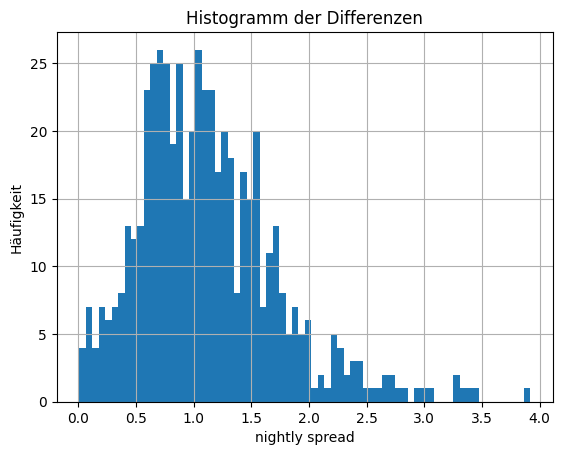

In [97]:

delta_10.hist(bins=n_bins)
plt.xlabel("nightly spread")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Differenzen")
plt.show()

A = 22.70234 ± 0.85900
mu = 0.98928 ± 0.02337
sigma = 0.53101 ± 0.02471
Chi² = 68.32
reduced Chi² = 1.02


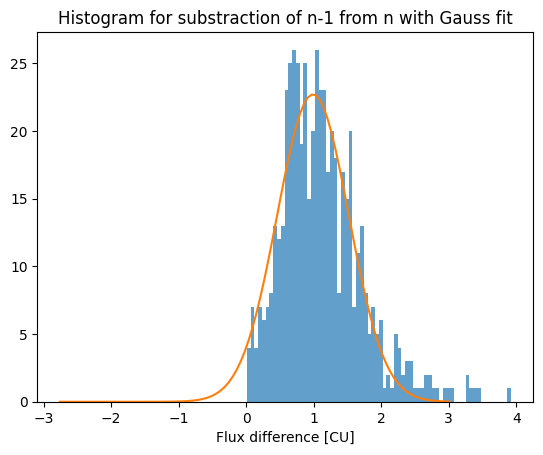

In [98]:
# Histogramm erzeugen
counts, bins = np.histogram(delta_10, bins=n_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Startwerte
p0 = [max(counts), np.mean(sub_nach), np.std(sub_nach)]

# Fit
popt, pcov = curve_fit(gauss, bin_centers, counts, p0=p0)

A, mu, sigma = popt
perr = np.sqrt(np.diag(pcov))
dA, dmu, dsigma = perr

print(f"A = {A:.5f} ± {dA:.5f}")
print(f"mu = {mu:.5f} ± {dmu:.5f}")
print(f"sigma = {sigma:.5f} ± {dsigma:.5f}")

# Chi² berechnen (Poisson-Fehler)
y_fit = gauss(bin_centers, *popt)
sigma_counts = np.sqrt(counts)
# Vermeide Division durch 0
sigma_counts[sigma_counts == 0] = 1.0

chi2 = np.sum(((counts - y_fit)/sigma_counts)**2)
dof = len(counts) - len(popt)
chi2_red = chi2 / dof

print(f"Chi² = {chi2:.2f}")
print(f"reduced Chi² = {chi2_red:.2f}")

# Plot
plt.hist(delta_10, bins=n_bins, alpha=0.7)
x = np.linspace(min(sub_nach), max(sub_nach), 100)
plt.plot(x, gauss(x, *popt))
plt.xlabel("Flux difference [CU]")
plt.title("Histogram for substraction of n-1 from n with Gauss fit")
plt.show()

#### Errors of binning

In [99]:
n_bins=40

In [100]:
CU_10_err = [item for sublist in nightly_delta_10["binning_CU_err"] for item in sublist]
CU_20_err = [item for sublist in nightly_delta_20["binning_CU_err"] for item in sublist]
CU_30_err = [item for sublist in nightly_delta_30["binning_CU_err"] for item in sublist]
CU_40_err = [item for sublist in nightly_delta_40["binning_CU_err"] for item in sublist]
CU_60_err = [item for sublist in nightly_delta_60["binning_CU_err"] for item in sublist]

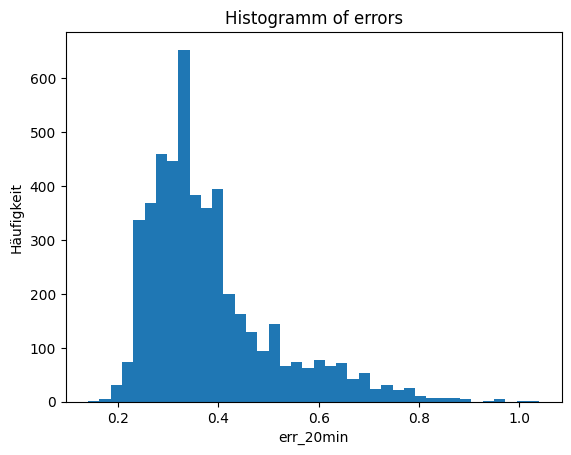

In [101]:
plt.hist(CU_60_err, bins=n_bins)
plt.xlabel("err_20min")
plt.ylabel("Häufigkeit")
plt.title("Histogramm of errors")
plt.show()

A = 515.76605 ± 28.61038
mu = 0.33069 ± 0.00475
sigma = 0.07419 ± 0.00478


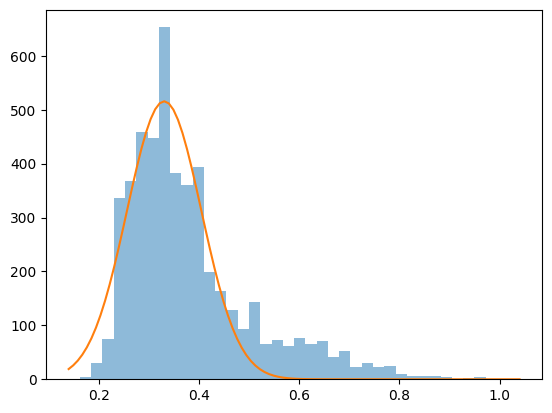

In [102]:
# Histogramm erzeugen
counts, bins = np.histogram(CU_20_err, bins=n_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Startwerte
p0 = [max(counts), np.mean(CU_20_err), np.std(CU_20_err)]

# Fit
popt, pcov = curve_fit(gauss, bin_centers, counts, p0=p0)

A, mu, sigma = popt

# Unsicherheiten (Wurzel der Diagonale der Kovarianzmatrix)
perr = np.sqrt(np.diag(pcov))
dA, dmu, dsigma = perr

print(f"A = {A:.5f} ± {dA:.5f}")
print(f"mu = {mu:.5f} ± {dmu:.5f}")
print(f"sigma = {sigma:.5f} ± {dsigma:.5f}")

plt.hist(CU_20_err, bins=n_bins, alpha=0.5)
x = np.linspace(min(CU_20_err), max(CU_20_err), 100)
plt.plot(x, gauss(x, *popt))
plt.show()


In [103]:
df_results_60

,gruppe,n,x_data,y_data,y_err_data,best_model,classification,AICc,Akaike_weight,params,all_params,errors,akaike_table
0,0,11,"[57037.0611, 57037.0834, 57037.1108, 57037.129...","[0.87, 0.7, 0.48, 1.1, 0.72, 1.21, 0.43, 0.84,...","[0.38, 0.33, 0.3, 0.33, 0.31, 0.35, 0.32, 0.33...",konstant,konstant/rauschen (Model),7.506919,0.798473,[0.7554862339347856],"{'konstant': [0.7554862339347856], 'linear': [...",[0.09397413655046576],AICc Delta weight konst...
1,1,13,"[57038.0616, 57038.0769, 57038.0921, 57038.111...","[1.12, 1.04, 1.28, 0.31, 0.31, 0.73, 0.8, 0.73...","[0.42, 0.38, 0.38, 0.31, 0.29, 0.31, 0.32, 0.3...",konstant,konstant/rauschen (Model),9.829230,0.784895,[0.735304816653022],"{'konstant': [0.735304816653022], 'linear': [-...",[0.09190401076086062],AICc Delta weight konsta...
2,2,13,"[57039.0577, 57039.0766, 57039.0919, 57039.107...","[0.35, 0.69, 0.25, 0.59, 0.46, 0.75, 0.34, 0.6...","[0.35, 0.36, 0.32, 0.32, 0.3, 0.31, 0.27, 0.29...",linear,konstant/rauschen (Model),4.512857,0.747652,"[-193288.27258076525, 3.3887060060563337]","{'konstant': [0.6723383568591321], 'linear': [...","[56563.7573453852, 0.9916653242714938]",AICc Delta weight linear...
3,3,14,"[57040.0551, 57040.0704, 57040.0894, 57040.104...","[1.08, 1.58, 0.97, 1.12, 1.33, 0.56, 1.12, 1.1...","[0.41, 0.41, 0.36, 0.36, 0.35, 0.28, 0.33, 0.3...",konstant,konstant/rauschen (Model),8.581019,0.781243,[1.0718936908134111],"{'konstant': [1.0718936908134111], 'linear': [...",[0.08086941360041709],AICc Delta weight konsta...
4,4,2,"[57041.2572, 57041.2724]","[1.52, 0.79]","[0.37, 0.35]",NaN,zu wenige daten,NaN,NaN,None,{},None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,3,"[58655.8843, 58655.9019, 58655.9135]","[0.18, -0.15, 0.19]","[0.46, 0.43, 0.44]",konstant,konstant/rauschen (Model),7.023835,1.000000,[0.06672219305593957],"{'konstant': [0.06672219305593957], 'linear': ...",[0.11335275275472279],AICc Delta weight konstant 7....
603,603,2,"[58656.885, 58656.9033]","[0.5, 0.58]","[0.49, 0.46]",NaN,zu wenige daten,NaN,NaN,None,{},None,None
604,604,3,"[58657.885, 58657.9027, 58657.9214]","[0.48, 1.3, 1.13]","[0.47, 0.51, 0.58]",konstant,konstant/rauschen (Model),9.129354,1.000000,[0.9282316388759528],"{'konstant': [0.9282316388759528], 'linear': [...",[0.26237655209400346],AICc Delta weight konstant 9....
605,605,3,"[58658.885, 58658.9012, 58658.9177]","[0.62, 0.55, 0.79]","[0.51, 0.5, 0.54]",konstant,konstant/rauschen (Model),7.658841,1.000000,[0.6468750736772615],"{'konstant': [0.6468750736772615], 'linear': [...",[0.07002533189422569],AICc Delta weight konstant 7....


In [104]:
from matplotlib.ticker import MaxNLocator


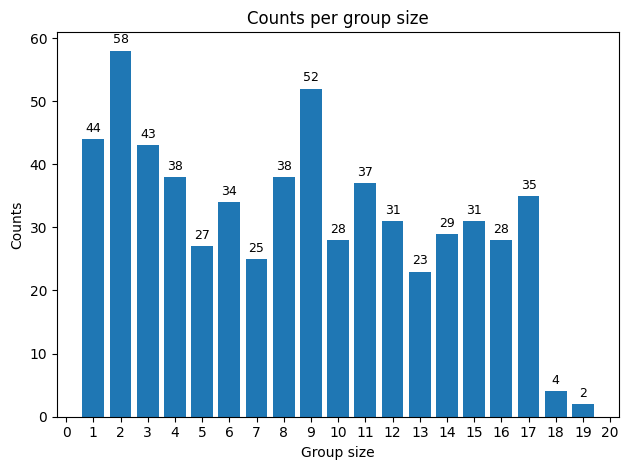

In [105]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots()
counts = df_results_60.n.value_counts().sort_index()
bars = ax.bar(counts.index, counts.values)
ax.xaxis.set_major_locator(MultipleLocator(1))   # ticks at every integer

# add labels on top
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h}',                    # format as needed, e.g. f'{h:.0f}'
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3),             # offset in points
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=9)
plt.title("Counts per group size")
ax.set_xlabel("Group size")
ax.set_ylabel("Counts")
plt.tight_layout()
plt.show()

## Constant-null candidate flagger

This section flags potential IDV candidates before morphology fitting. The flag is based on rejecting the constant-flux null model after FDR correction, plus at least one supporting variability metric.


In [106]:
import importlib
import meine_Funktionen
importlib.reload(meine_Funktionen)

daten421_20 = meine_Funktionen.load_data('FACT_preliminary_421_20min_150101_191231_katha.dat')
daten421_n = meine_Funktionen.load_data('FACT_preliminary_421_nightly_150101_191231_katha.dat')


### Check whether a 0.5 day gap separates observing nights

A 0.5 day gap is probably conservative for FACT nightly runs, but this diagnostic checks the actual gap distribution. The important question is whether there is a clean separation between intra-night cadence and inter-night gaps.


In [107]:
daten421_20

,MJD,MJD_err,CU,CU_err,Flux,Flux_err,MJDstop,ontime
0,57037.0611,0.00940,0.87,0.38,2.740000e-11,1.190000e-11,57037.0799,19.1
1,57037.0834,0.01125,0.70,0.33,2.210000e-11,1.050000e-11,57037.1059,18.8
2,57037.1108,0.00940,0.48,0.30,1.520000e-11,9.500000e-12,57037.1296,19.4
3,57037.1297,0.00755,1.10,0.33,3.460000e-11,1.040000e-11,57037.1448,19.4
4,57037.1449,0.00945,0.72,0.31,2.260000e-11,9.700000e-12,57037.1638,19.5
...,...,...,...,...,...,...,...,...
5104,58658.8850,0.00805,0.62,0.51,1.960000e-11,1.600000e-11,58658.9011,19.2
5105,58658.9012,0.00820,0.55,0.50,1.730000e-11,1.570000e-11,58658.9176,16.1
5106,58658.9177,0.00800,0.79,0.54,2.470000e-11,1.690000e-11,58658.9337,18.8
5107,58661.9003,0.00890,-0.11,0.45,-3.400000e-12,1.410000e-11,58661.9181,18.9


In [108]:
daten421_20

,MJD,MJD_err,CU,CU_err,Flux,Flux_err,MJDstop,ontime
0,57037.0611,0.00940,0.87,0.38,2.740000e-11,1.190000e-11,57037.0799,19.1
1,57037.0834,0.01125,0.70,0.33,2.210000e-11,1.050000e-11,57037.1059,18.8
2,57037.1108,0.00940,0.48,0.30,1.520000e-11,9.500000e-12,57037.1296,19.4
3,57037.1297,0.00755,1.10,0.33,3.460000e-11,1.040000e-11,57037.1448,19.4
4,57037.1449,0.00945,0.72,0.31,2.260000e-11,9.700000e-12,57037.1638,19.5
...,...,...,...,...,...,...,...,...
5104,58658.8850,0.00805,0.62,0.51,1.960000e-11,1.600000e-11,58658.9011,19.2
5105,58658.9012,0.00820,0.55,0.50,1.730000e-11,1.570000e-11,58658.9176,16.1
5106,58658.9177,0.00800,0.79,0.54,2.470000e-11,1.690000e-11,58658.9337,18.8
5107,58661.9003,0.00890,-0.11,0.45,-3.400000e-12,1.410000e-11,58661.9181,18.9


In [109]:
gap_diagnostics = meine_Funktionen.diagnose_grouping_gaps(daten421_20, spalte='MJD')
gap_diagnostics['gap_hours'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    5108.000000
mean        7.239588
std        97.771922
min         0.000000
50%         0.007200
90%        18.258000
95%        21.833520
99%        95.554464
max      3798.285600
Name: gap_hours, dtype: float64

Text(0.5, 1.0, 'Observed cadence gaps')

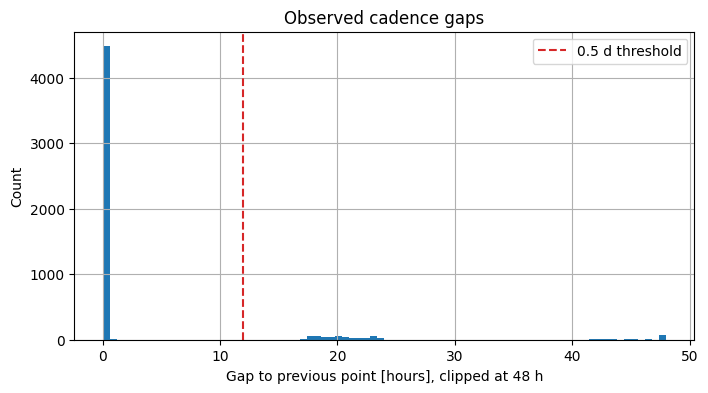

In [110]:
fig, ax = plt.subplots(figsize=(8, 4))
gap_diagnostics['gap_hours'].clip(upper=48).hist(bins=80, ax=ax)
ax.axvline(12, color='tab:red', linestyle='--', label='0.5 d threshold')
ax.set_xlabel('Gap to previous point [hours], clipped at 48 h')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Observed cadence gaps')


### Run the candidate flagger

Candidate rule: `q_const < 0.05` and at least one of `F_var_lower > 0`, `max_adjacent_sigma > 3`, or `range_p_mc < 0.01`. Use `n_sim=10000` for final numbers; lower it while iterating if needed.


In [111]:
daten421_20_gap = meine_Funktionen.gruppiere_datenpunkte(daten421_20, 0.5, 'MJD')
daten421_20_gap_groups = {gruppe: daten for gruppe, daten in daten421_20_gap.groupby('Gruppe')}

candidate_results_20 = meine_Funktionen.flag_candidate_groups(
    daten421_20_gap_groups,
    n_sim=10000,
    random_state=42,
    min_points=3,
    min_strong_points=5,
    q_const_threshold=0.10,
    possible_q_const_threshold=0.50,
)

candidate_results_20['candidate_class'].value_counts()


candidate_class
not_candidate         476
not_testable          102
possible_candidate     27
strong_candidate        1
candidate               1
Name: count, dtype: int64

In [112]:
candidate_summary_cols = [
    'gruppe', 'candidate_class', 'n', 'duration_hours', 'p_const', 'q_const',
    'F_var', 'F_var_err', 'F_var_lower', 'max_adjacent_sigma',
    'range_CU', 'range_p_mc', 'support_fvar', 'support_adjacent', 'support_range_mc'
]

candidate_results_20.loc[
    candidate_results_20['is_candidate'], candidate_summary_cols
].sort_values([
    'candidate_class', 'q_const', 'range_p_mc'
])


,gruppe,candidate_class,n,duration_hours,p_const,q_const,F_var,F_var_err,F_var_lower,max_adjacent_sigma,range_CU,range_p_mc,support_fvar,support_adjacent,support_range_mc
1,349,candidate,13,4.5936,1.971741e-04,4.978647e-02,0.177063,0.031456,0.145607,3.429747,3.47,0.001500,True,True,True
2,550,possible_candidate,14,5.3904,6.417903e-04,1.080347e-01,0.254216,0.056670,0.197546,2.899760,3.02,0.015498,True,True,True
3,25,possible_candidate,9,3.4584,1.288794e-03,1.627103e-01,0.411426,0.089277,0.322149,1.763485,2.64,0.001800,True,False,True
4,347,possible_candidate,15,4.9728,2.248746e-03,2.271233e-01,0.289859,0.063137,0.226721,2.748909,2.13,0.019798,True,True,True
5,346,possible_candidate,14,4.9704,3.061310e-03,2.487313e-01,0.264473,0.070362,0.194111,4.424769,2.43,0.001400,True,True,True
6,477,possible_candidate,10,3.1992,3.447760e-03,2.487313e-01,2.748283,0.700761,2.047521,2.604755,2.76,0.018598,True,True,True
7,197,possible_candidate,8,2.4984,4.319582e-03,2.726736e-01,1.934784,0.564447,1.370337,2.274208,2.21,0.010699,True,False,True
8,399,possible_candidate,9,4.7784,5.724005e-03,2.890622e-01,0.705187,0.185049,0.520138,3.531133,1.43,0.006799,True,True,True
9,339,possible_candidate,11,3.5232,5.575295e-03,2.890622e-01,0.164160,0.046253,0.117907,2.542829,2.23,0.072293,True,True,False
10,32,possible_candidate,3,0.7296,6.725347e-03,3.087546e-01,0.387861,0.114842,0.273019,2.832227,1.65,0.020398,True,True,True


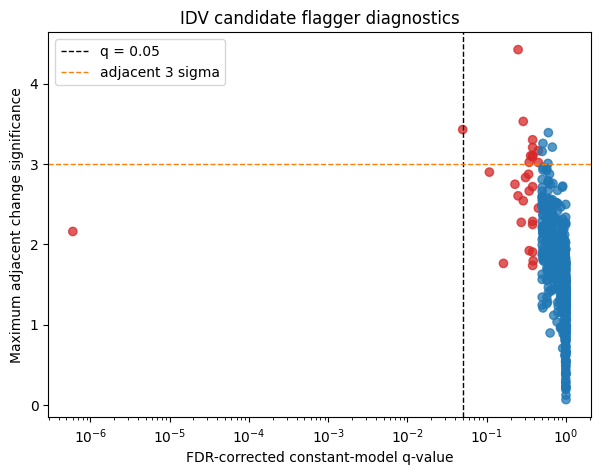

In [113]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = candidate_results_20['is_candidate'].map({True: 'tab:red', False: 'tab:blue'})
ax.scatter(candidate_results_20['q_const'], candidate_results_20['max_adjacent_sigma'], c=colors, alpha=0.75)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1, label='q = 0.05')
ax.axhline(3, color='tab:orange', linestyle='--', linewidth=1, label='adjacent 3 sigma')
ax.set_xscale('log')
ax.set_xlabel('FDR-corrected constant-model q-value')
ax.set_ylabel('Maximum adjacent change significance')
ax.set_title('IDV candidate flagger diagnostics')
ax.legend()


### Optional: compare against MJD-night grouping

This keeps the same flagging rule but changes only the grouping definition. Large disagreement with the gap grouping means the grouping choice should be reviewed before interpreting candidates.


In [114]:
daten421_20_mjdnight = meine_Funktionen.gruppiere_nach_mjd_nacht(daten421_20, spalte='MJD', mjd_offset=0.5)
candidate_results_20_mjdnight = meine_Funktionen.flag_candidate_groups(
    daten421_20_mjdnight,
    n_sim=10000,
    random_state=42,
    min_points=3,
    min_strong_points=5,
    q_const_threshold=0.30,
    possible_q_const_threshold=0.50,
)

pd.DataFrame({
    'gap_0p5d': candidate_results_20['candidate_class'].value_counts(),
    'mjd_night': candidate_results_20_mjdnight['candidate_class'].value_counts(),
}).fillna(0).astype(int)


,gap_0p5d,mjd_night
candidate_class,,
candidate,1,9
not_candidate,476,476
not_testable,102,102
possible_candidate,27,19
strong_candidate,1,1


In [115]:
__daten421_20_mjdnight = meine_Funktionen.flag_candidate_groups(daten421_20_mjdnight, q_const_threshold=0.50,)

__daten421_20_mjdnight['candidate_class'].value_counts(),

(candidate_class
 not_candidate       476
 not_testable        102
 candidate            28
 strong_candidate      1
 Name: count, dtype: int64,)

In [116]:
candidate_results_20

,gruppe,candidate_class,is_candidate,n,duration_hours,weighted_mean,chi2_const,dof_const,p_const,q_const,...,support_range_mc,passes_possible_q_const,passes_q_const,passes_strong_q_const,passes_strong_range_mc,passes_min_strong_points,candidate_criteria,x_data,y_data,y_err_data
0,351,strong_candidate,True,15,5.4000,2.762097,71.156001,14.0,1.190926e-09,6.014176e-07,...,True,True,True,True,True,True,q_const < 0.01; range MC p < 0.01; F_var suppo...,"[58137.0461, 58137.0604, 58137.0783, 58137.094...","[3.84, 4.73, 4.4, 3.77, 3.81, 3.34, 3.79, 3.13...","[0.58, 0.62, 0.56, 0.52, 0.51, 0.46, 0.49, 0.4..."
1,349,candidate,True,13,4.5936,4.712980,37.334090,12.0,1.971741e-04,4.978647e-02,...,True,True,True,False,True,True,q_const < candidate threshold; range MC p < 0....,"[58135.0522, 58135.0809, 58135.0967, 58135.111...","[4.03, 4.12, 5.58, 4.63, 5.96, 5.87, 7.14, 4.3...","[0.55, 0.52, 0.59, 0.54, 0.59, 0.59, 0.63, 0.5..."
2,550,possible_candidate,True,14,5.3904,2.428430,35.780149,13.0,6.417903e-04,1.080347e-01,...,True,True,False,False,False,True,q_const < possible threshold; range MC support...,"[58584.9113, 58584.9401, 58584.9546, 58584.970...","[1.35, 2.13, 2.49, 1.74, 2.23, 1.57, 2.68, 4.3...","[0.43, 0.46, 0.48, 0.44, 0.47, 0.41, 0.47, 0.5..."
3,25,possible_candidate,True,9,3.4584,1.673620,25.479355,8.0,1.288794e-03,1.627103e-01,...,True,True,False,False,True,True,q_const < possible threshold; range MC p < 0.0...,"[57092.9817, 57093.0007, 57093.0161, 57093.031...","[3.15, 2.39, 1.89, 2.03, 0.97, 1.87, 0.95, 1.3...","[0.48, 0.43, 0.41, 0.43, 0.42, 0.47, 0.45, 0.4..."
4,347,possible_candidate,True,15,4.9728,1.539854,33.742525,14.0,2.248746e-03,2.271233e-01,...,True,True,False,False,False,True,q_const < possible threshold; range MC support...,"[58131.0613, 58131.0757, 58131.0916, 58131.105...","[2.03, 2.4, 1.82, 2.83, 2.16, 1.25, 2.59, 1.1,...","[0.48, 0.49, 0.42, 0.47, 0.42, 0.35, 0.43, 0.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,593,not_testable,False,2,0.4224,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,no candidate criteria passed,"[58643.8815, 58643.8991]","[2.02, 0.26]","[0.64, 0.57]"
603,599,not_testable,False,2,0.3456,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,no candidate criteria passed,"[58652.9157, 58652.9301]","[0.03, -0.54]","[0.6, 0.67]"
604,601,not_testable,False,2,0.5256,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,no candidate criteria passed,"[58654.8843, 58654.9062]","[0.1, 1.11]","[0.48, 0.46]"
605,603,not_testable,False,2,0.4392,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,no candidate criteria passed,"[58656.885, 58656.9033]","[0.5, 0.58]","[0.49, 0.46]"


In [117]:
candidate_results_20[candidate_results_20["candidate_class"].isin(["strong_candidate","candidate","review"])].sort_values(by="gruppe")

,gruppe,candidate_class,is_candidate,n,duration_hours,weighted_mean,chi2_const,dof_const,p_const,q_const,...,support_range_mc,passes_possible_q_const,passes_q_const,passes_strong_q_const,passes_strong_range_mc,passes_min_strong_points,candidate_criteria,x_data,y_data,y_err_data
1,349,candidate,True,13,4.5936,4.712980,37.334090,12.0,1.971741e-04,4.978647e-02,...,True,True,True,False,True,True,q_const < candidate threshold; range MC p < 0....,"[58135.0522, 58135.0809, 58135.0967, 58135.111...","[4.03, 4.12, 5.58, 4.63, 5.96, 5.87, 7.14, 4.3...","[0.55, 0.52, 0.59, 0.54, 0.59, 0.59, 0.63, 0.5..."
0,351,strong_candidate,True,15,5.4000,2.762097,71.156001,14.0,1.190926e-09,6.014176e-07,...,True,True,True,True,True,True,q_const < 0.01; range MC p < 0.01; F_var suppo...,"[58137.0461, 58137.0604, 58137.0783, 58137.094...","[3.84, 4.73, 4.4, 3.77, 3.81, 3.34, 3.79, 3.13...","[0.58, 0.62, 0.56, 0.52, 0.51, 0.46, 0.49, 0.4..."


In [118]:
__daten421_20_mjdnight[__daten421_20_mjdnight["candidate_class"].isin(["strong_candidate","candidate","review"])].sort_values(by="gruppe")

,gruppe,candidate_class,is_candidate,n,duration_hours,mjd_nacht,weighted_mean,chi2_const,dof_const,p_const,...,support_range_mc,passes_possible_q_const,passes_q_const,passes_strong_q_const,passes_strong_range_mc,passes_min_strong_points,candidate_criteria,x_data,y_data,y_err_data
26,6,candidate,True,14,5.2128,57042,0.947707,24.744103,13.0,2.493619e-02,...,True,True,True,False,False,True,q_const < candidate threshold; range MC suppor...,"[57042.0562, 57042.0715, 57042.0905, 57042.105...","[1.51, 0.86, 0.89, -0.02, 1.01, 0.78, 1.28, 0....","[0.4, 0.35, 0.33, 0.26, 0.33, 0.31, 0.35, 0.32..."
18,13,candidate,True,10,4.9296,57066,1.273765,20.209418,9.0,1.666309e-02,...,True,True,True,False,False,True,q_const < candidate threshold; range MC suppor...,"[57065.9866, 57066.0056, 57066.0244, 57066.039...","[2.32, 0.46, 1.35, 1.98, 1.96, 1.31, 0.91, 1.0...","[0.47, 0.34, 0.36, 0.39, 0.37, 0.32, 0.3, 0.33..."
27,21,candidate,True,4,2.9592,57081,0.434436,9.305095,3.0,2.549783e-02,...,True,True,True,False,False,False,q_const < candidate threshold; range MC suppor...,"[57081.0719, 57081.145, 57081.18, 57081.1952]","[0.57, 1.3, -0.2, 0.34]","[0.39, 0.38, 0.32, 0.37]"
3,26,candidate,True,9,3.4584,57093,1.673620,25.479355,8.0,1.288794e-03,...,True,True,True,False,True,True,q_const < candidate threshold; range MC p < 0....,"[57092.9817, 57093.0007, 57093.0161, 57093.031...","[3.15, 2.39, 1.89, 2.03, 0.97, 1.87, 0.95, 1.3...","[0.48, 0.43, 0.41, 0.43, 0.42, 0.47, 0.45, 0.4..."
10,33,candidate,True,3,0.7296,57108,1.874604,10.003743,2.0,6.725347e-03,...,True,True,True,False,False,False,q_const < candidate threshold; range MC suppor...,"[57108.0651, 57108.0803, 57108.0955]","[1.0, 2.65, 2.44]","[0.37, 0.45, 0.47]"
25,43,candidate,True,9,3.1992,57124,2.414857,18.184260,8.0,1.988670e-02,...,False,True,True,False,False,True,q_const < candidate threshold; F_var support; ...,"[57123.9084, 57123.9237, 57123.9425, 57123.961...","[3.26, 3.43, 3.21, 2.13, 2.15, 1.78, 2.46, 1.7...","[0.46, 0.46, 0.44, 0.41, 0.42, 0.38, 0.42, 0.3..."
22,116,candidate,True,12,4.2456,57395,0.527746,23.845492,11.0,1.340056e-02,...,False,True,True,False,False,True,q_const < candidate threshold; F_var support; ...,"[57395.088, 57395.1023, 57395.1167, 57395.131,...","[0.39, 1.35, 0.19, -0.15, 0.02, 0.65, 0.5, 0.9...","[0.39, 0.42, 0.3, 0.29, 0.28, 0.31, 0.29, 0.33..."
19,156,candidate,True,13,5.4672,57458,0.134708,24.298657,12.0,1.851922e-02,...,True,True,True,False,False,True,q_const < candidate threshold; range MC suppor...,"[57457.9111, 57457.9254, 57457.9413, 57457.955...","[0.25, 0.22, -0.06, 0.27, 0.62, 0.89, 0.47, -0...","[0.37, 0.33, 0.3, 0.29, 0.29, 0.32, 0.29, 0.2,..."
15,172,candidate,True,10,5.2056,57483,-0.046953,21.310312,9.0,1.134162e-02,...,False,True,True,False,False,True,q_const < candidate threshold; F_var support; ...,"[57482.8516, 57482.9156, 57482.9299, 57482.944...","[0.67, -0.3, -0.51, 0.56, 0.13, 0.16, 0.41, 0....","[0.46, 0.22, 0.17, 0.3, 0.25, 0.24, 0.28, 0.27..."
7,198,candidate,True,8,2.4984,57521,0.158971,20.652746,7.0,4.319582e-03,...,True,True,True,False,False,True,q_const < candidate threshold; range MC suppor...,"[57520.8689, 57520.8838, 57520.8982, 57520.914...","[-1.21, -0.02, 0.45, 0.28, 1.0, 0.95, 0.3, 0.46]","[0.37, 0.37, 0.42, 0.41, 0.49, 0.48, 0.47, 0.47]"


In [119]:
__daten421_20_mjdnight = meine_Funktionen.flag_candidate_groups(daten421_20_mjdnight, q_const_threshold=0.30,possible_q_const_threshold=0.50,)
__daten421_20_mjdnight['candidate_class'].value_counts(),

(candidate_class
 not_candidate         476
 not_testable          102
 possible_candidate     19
 candidate               9
 strong_candidate        1
 Name: count, dtype: int64,)

In [120]:
__daten421_20_mjdnight.columns

Index(['gruppe', 'candidate_class', 'is_candidate', 'n', 'duration_hours',
       'mjd_nacht', 'weighted_mean', 'chi2_const', 'dof_const', 'p_const',
       'q_const', 'F_var', 'F_var_err', 'F_var_lower', 'max_adjacent_sigma',
       'range_CU', 'range_p_mc', 'support_fvar', 'support_adjacent',
       'support_range_mc', 'passes_possible_q_const', 'passes_q_const',
       'passes_strong_q_const', 'passes_strong_range_mc',
       'passes_min_strong_points', 'candidate_criteria', 'x_data', 'y_data',
       'y_err_data'],
      dtype='str')

In [121]:
__daten421_20_mjdnight["candidate_class"].value_counts()

candidate_class
not_candidate         476
not_testable          102
possible_candidate     19
candidate               9
strong_candidate        1
Name: count, dtype: int64

In [125]:
df


,gruppe,candidate_class,is_candidate,n,duration_hours,mjd_nacht,weighted_mean,chi2_const,dof_const,p_const,...,support_range_mc,passes_possible_q_const,passes_q_const,passes_strong_q_const,passes_strong_range_mc,passes_min_strong_points,candidate_criteria,x_data,y_data,y_err_data
26,6,possible_candidate,True,14,5.2128,57042,0.947707,24.744103,13.0,2.493619e-02,...,True,True,False,False,False,True,q_const < possible threshold; range MC support...,"[57042.0562, 57042.0715, 57042.0905, 57042.105...","[1.51, 0.86, 0.89, -0.02, 1.01, 0.78, 1.28, 0....","[0.4, 0.35, 0.33, 0.26, 0.33, 0.31, 0.35, 0.32..."
18,13,possible_candidate,True,10,4.9296,57066,1.273765,20.209418,9.0,1.666309e-02,...,True,True,False,False,False,True,q_const < possible threshold; range MC support...,"[57065.9866, 57066.0056, 57066.0244, 57066.039...","[2.32, 0.46, 1.35, 1.98, 1.96, 1.31, 0.91, 1.0...","[0.47, 0.34, 0.36, 0.39, 0.37, 0.32, 0.3, 0.33..."
27,21,possible_candidate,True,4,2.9592,57081,0.434436,9.305095,3.0,2.549783e-02,...,True,True,False,False,False,False,q_const < possible threshold; range MC support...,"[57081.0719, 57081.145, 57081.18, 57081.1952]","[0.57, 1.3, -0.2, 0.34]","[0.39, 0.38, 0.32, 0.37]"
3,26,candidate,True,9,3.4584,57093,1.673620,25.479355,8.0,1.288794e-03,...,True,True,True,False,True,True,q_const < candidate threshold; range MC p < 0....,"[57092.9817, 57093.0007, 57093.0161, 57093.031...","[3.15, 2.39, 1.89, 2.03, 0.97, 1.87, 0.95, 1.3...","[0.48, 0.43, 0.41, 0.43, 0.42, 0.47, 0.45, 0.4..."
10,33,possible_candidate,True,3,0.7296,57108,1.874604,10.003743,2.0,6.725347e-03,...,True,True,False,False,False,False,q_const < possible threshold; range MC support...,"[57108.0651, 57108.0803, 57108.0955]","[1.0, 2.65, 2.44]","[0.37, 0.45, 0.47]"
25,43,possible_candidate,True,9,3.1992,57124,2.414857,18.184260,8.0,1.988670e-02,...,False,True,False,False,False,True,q_const < possible threshold; F_var support; n...,"[57123.9084, 57123.9237, 57123.9425, 57123.961...","[3.26, 3.43, 3.21, 2.13, 2.15, 1.78, 2.46, 1.7...","[0.46, 0.46, 0.44, 0.41, 0.42, 0.38, 0.42, 0.3..."
22,116,possible_candidate,True,12,4.2456,57395,0.527746,23.845492,11.0,1.340056e-02,...,False,True,False,False,False,True,q_const < possible threshold; F_var support; n...,"[57395.088, 57395.1023, 57395.1167, 57395.131,...","[0.39, 1.35, 0.19, -0.15, 0.02, 0.65, 0.5, 0.9...","[0.39, 0.42, 0.3, 0.29, 0.28, 0.31, 0.29, 0.33..."
19,156,possible_candidate,True,13,5.4672,57458,0.134708,24.298657,12.0,1.851922e-02,...,True,True,False,False,False,True,q_const < possible threshold; range MC support...,"[57457.9111, 57457.9254, 57457.9413, 57457.955...","[0.25, 0.22, -0.06, 0.27, 0.62, 0.89, 0.47, -0...","[0.37, 0.33, 0.3, 0.29, 0.29, 0.32, 0.29, 0.2,..."
15,172,possible_candidate,True,10,5.2056,57483,-0.046953,21.310312,9.0,1.134162e-02,...,False,True,False,False,False,True,q_const < possible threshold; F_var support; a...,"[57482.8516, 57482.9156, 57482.9299, 57482.944...","[0.67, -0.3, -0.51, 0.56, 0.13, 0.16, 0.41, 0....","[0.46, 0.22, 0.17, 0.3, 0.25, 0.24, 0.28, 0.27..."
7,198,candidate,True,8,2.4984,57521,0.158971,20.652746,7.0,4.319582e-03,...,True,True,True,False,False,True,q_const < candidate threshold; range MC suppor...,"[57520.8689, 57520.8838, 57520.8982, 57520.914...","[-1.21, -0.02, 0.45, 0.28, 1.0, 0.95, 0.3, 0.46]","[0.37, 0.37, 0.42, 0.41, 0.49, 0.48, 0.47, 0.47]"


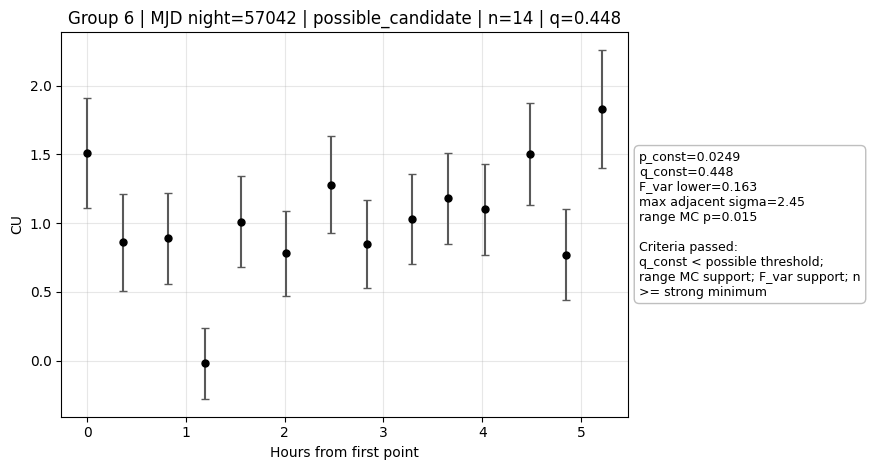

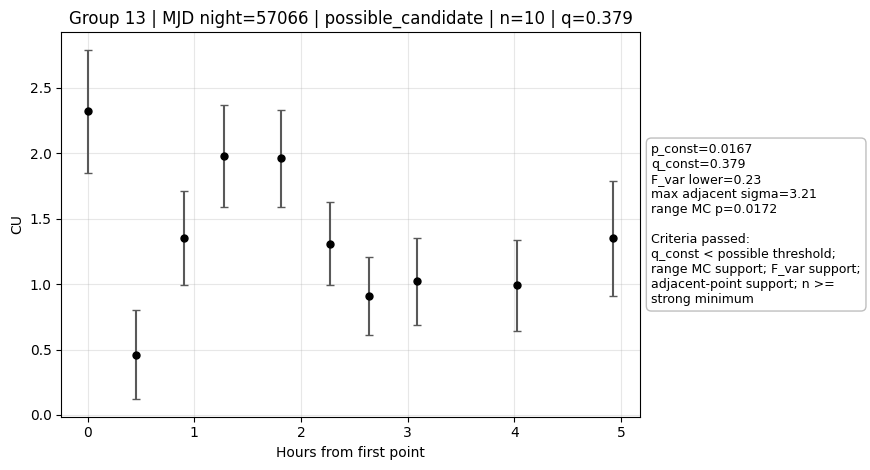

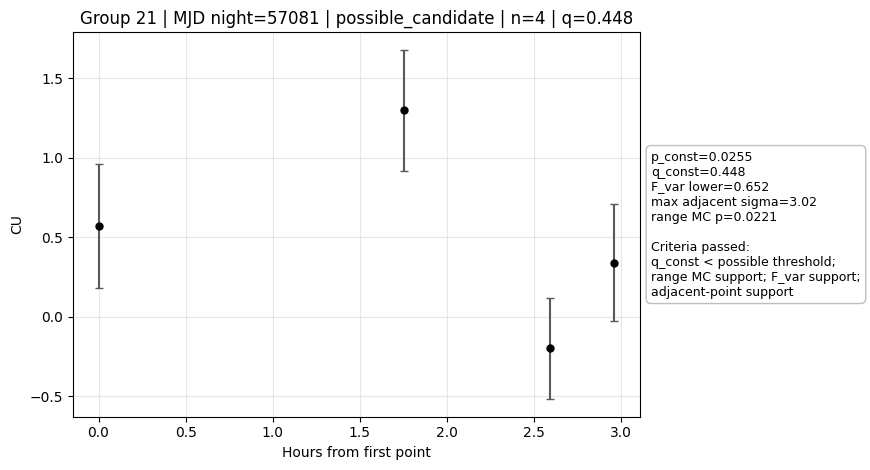

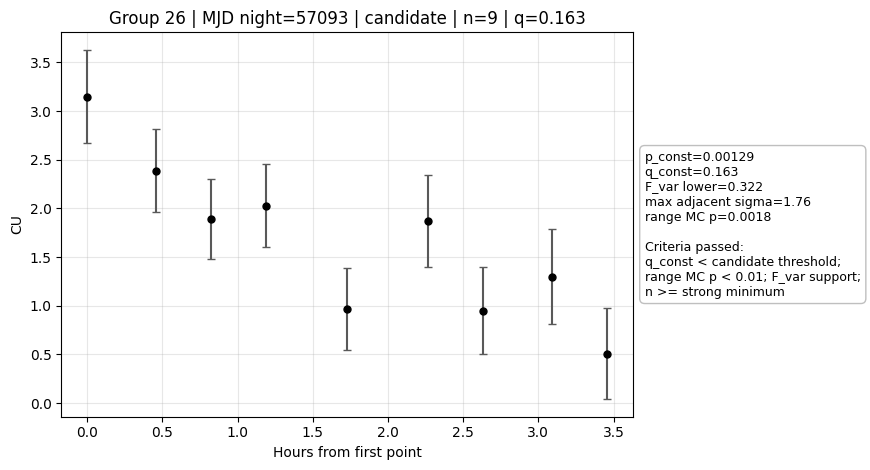

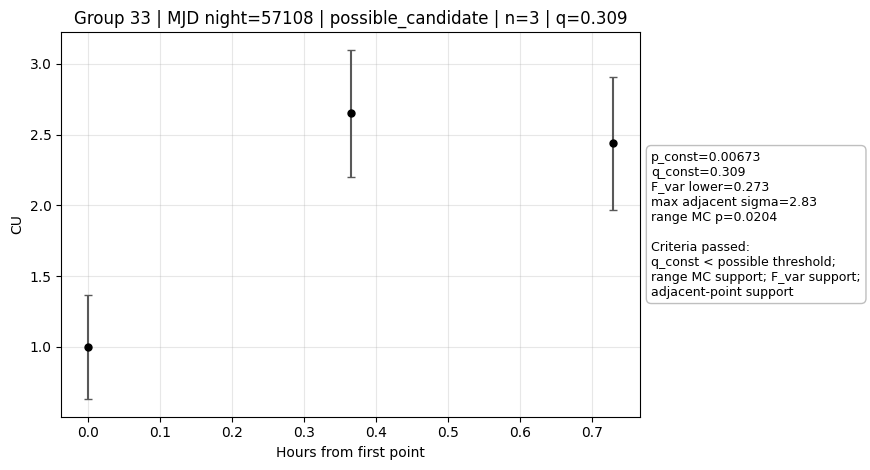

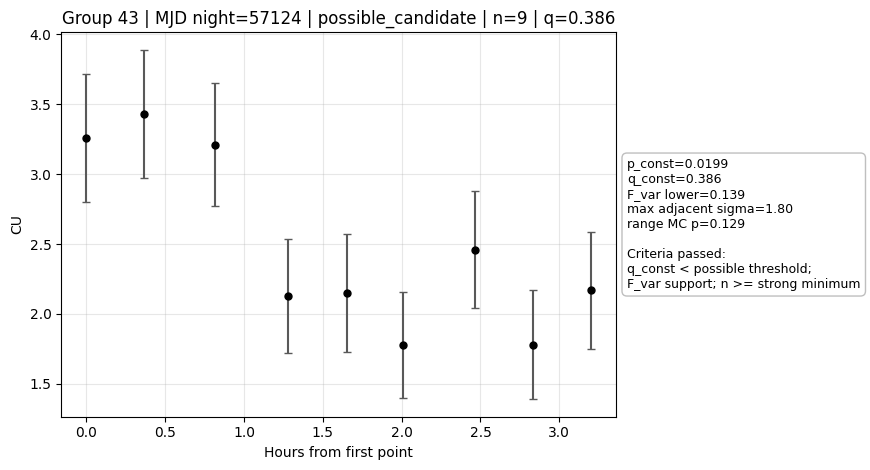

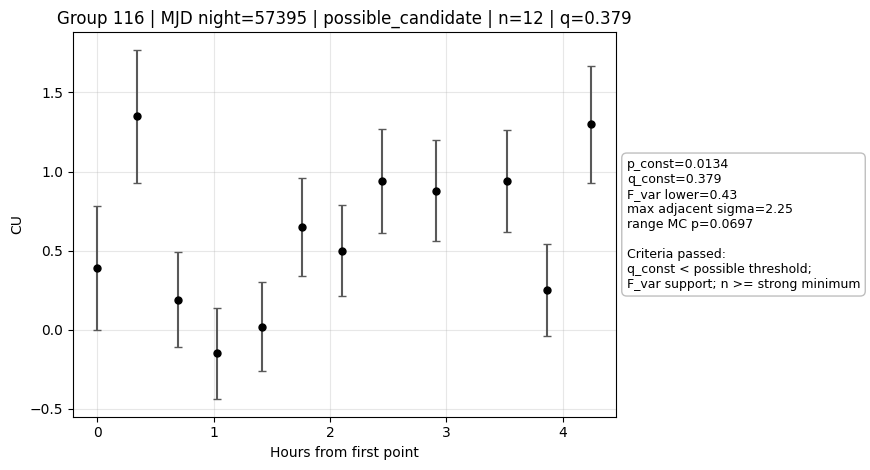

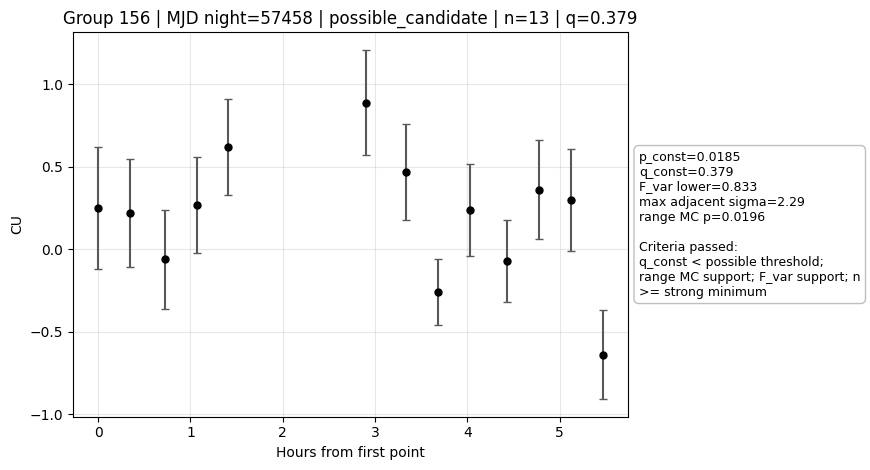

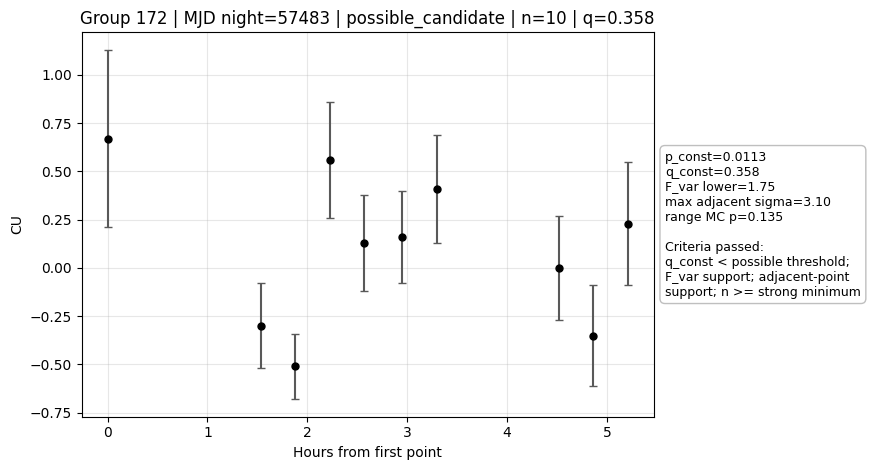

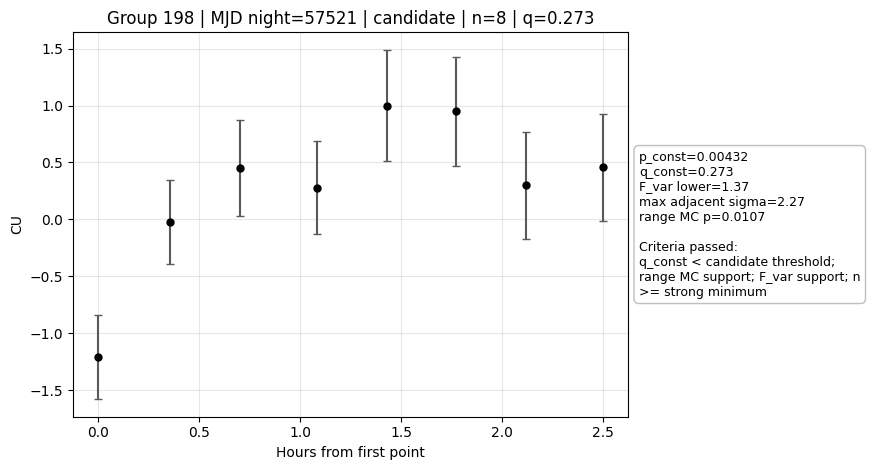

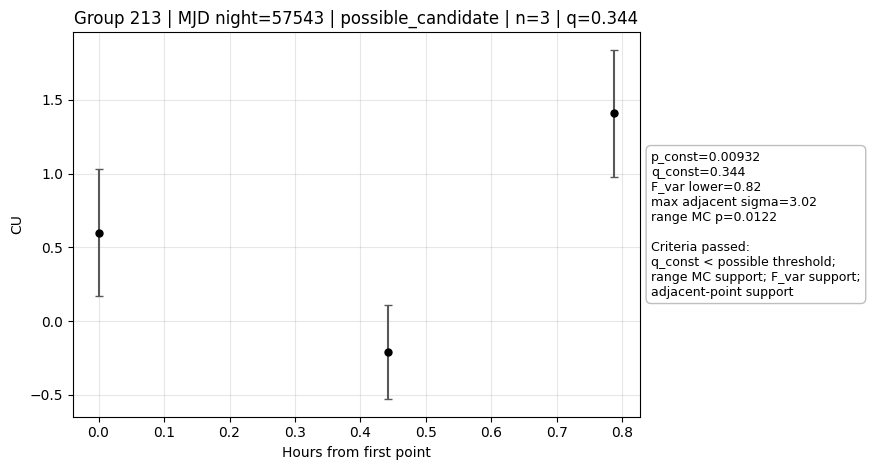

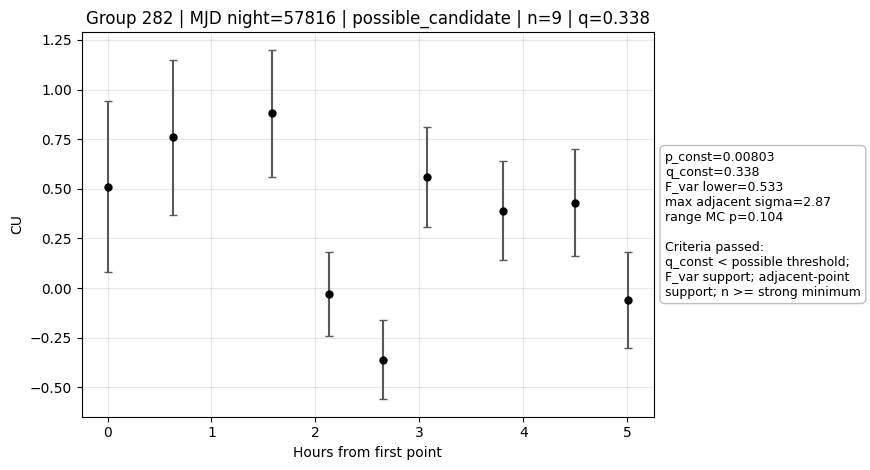

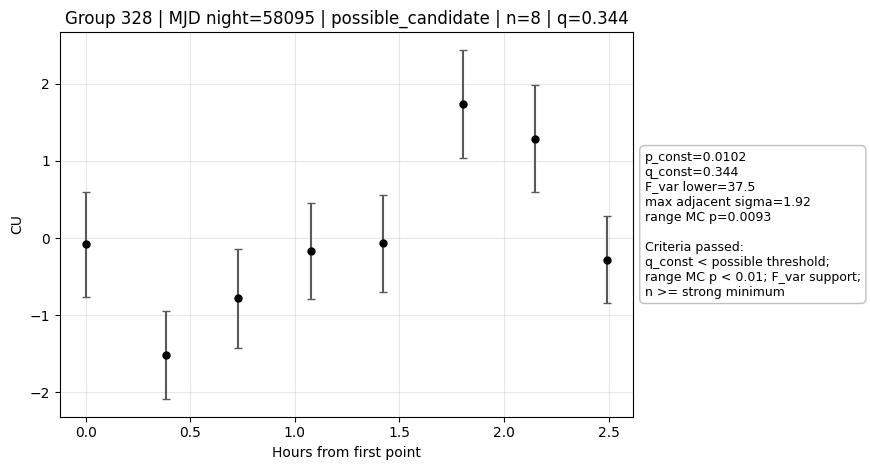

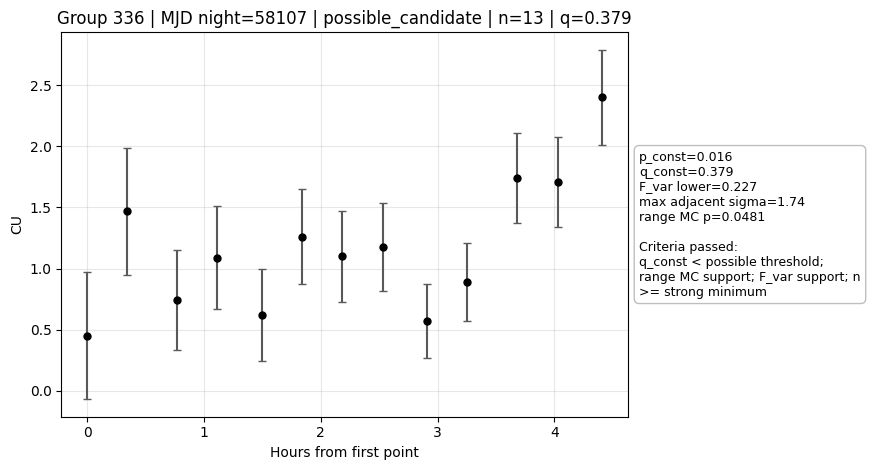

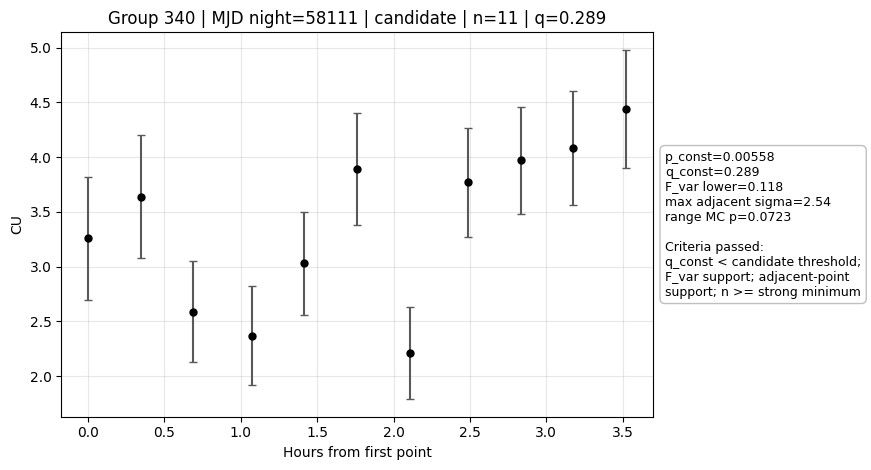

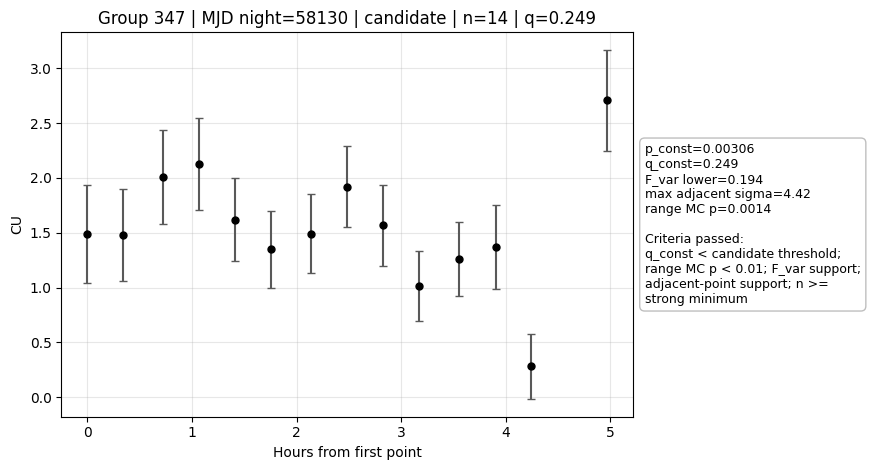

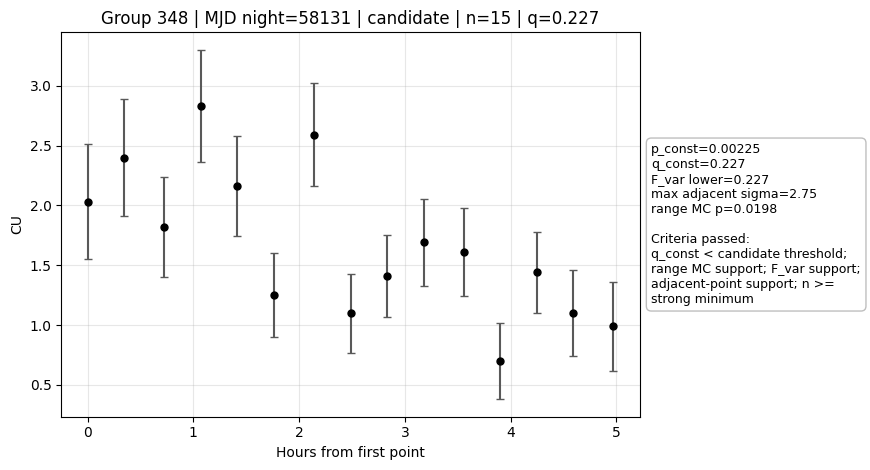

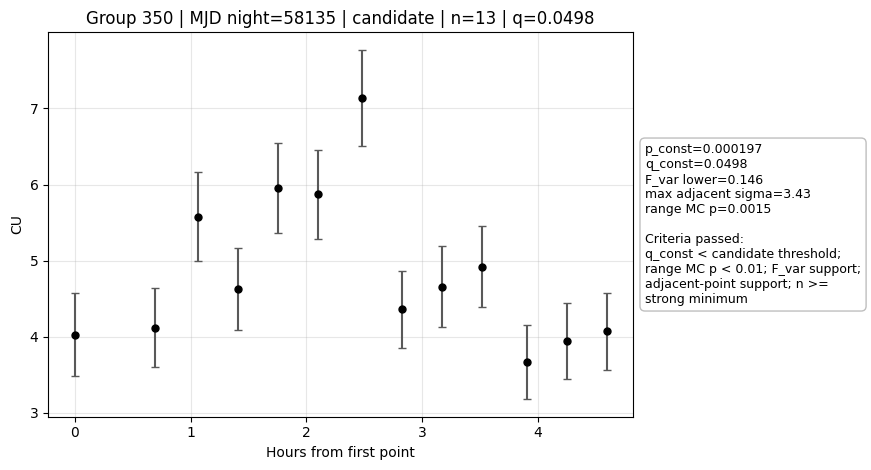

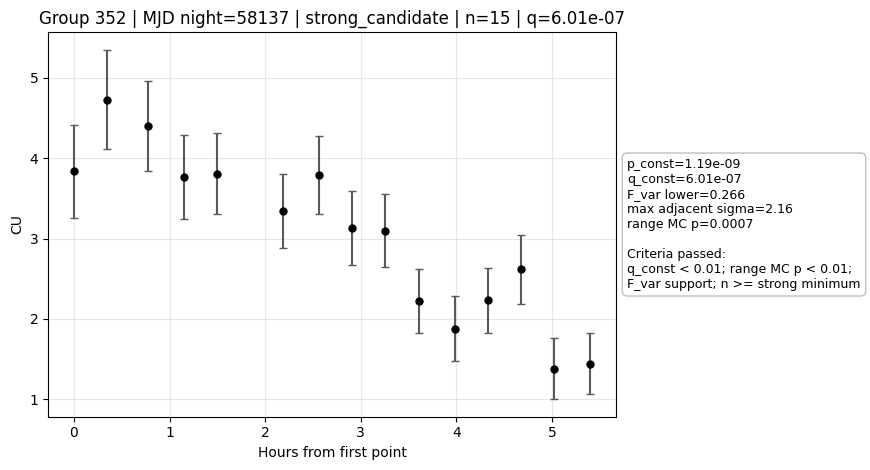

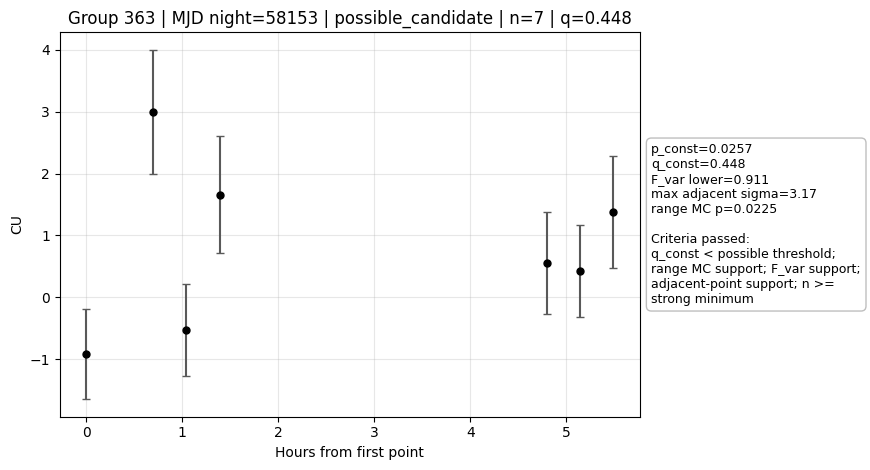

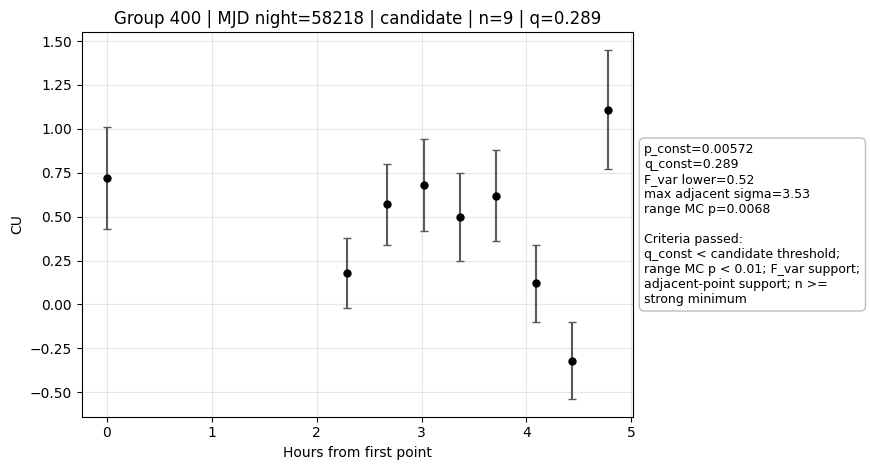

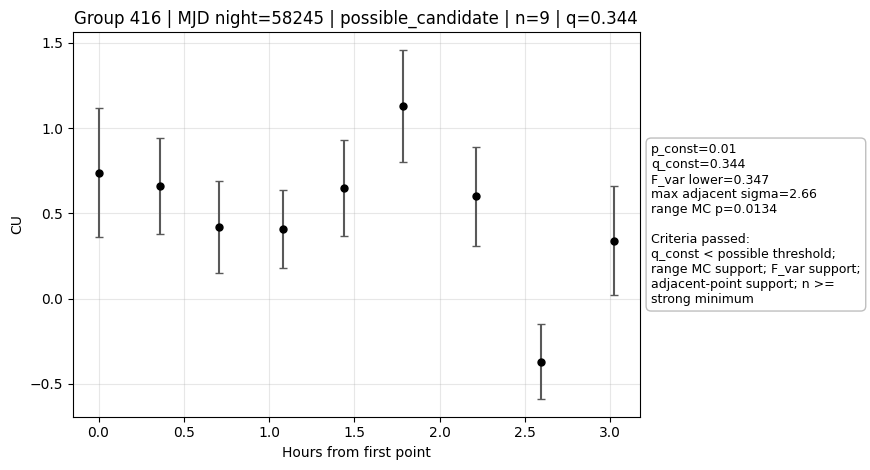

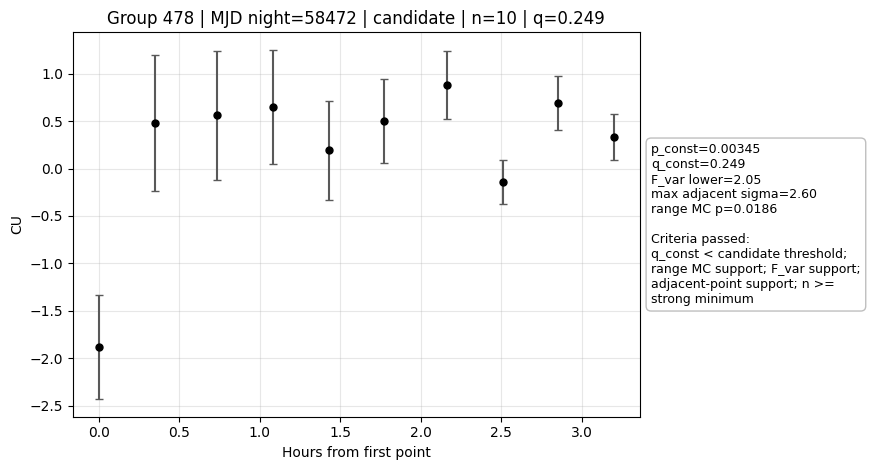

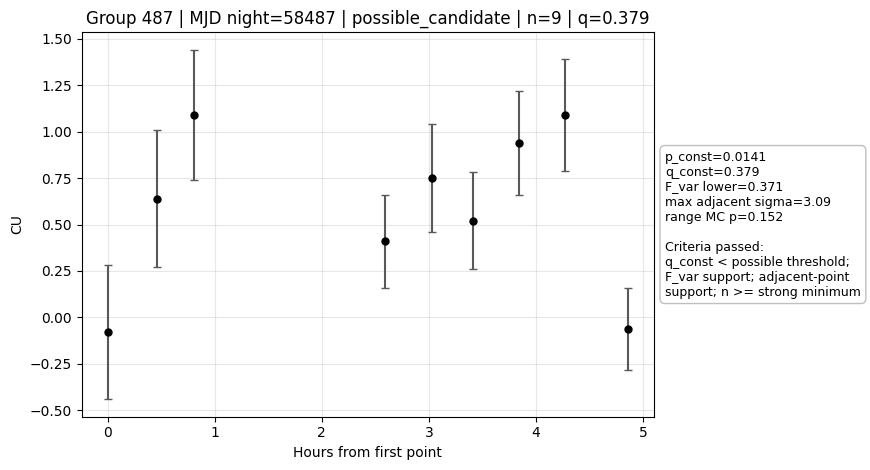

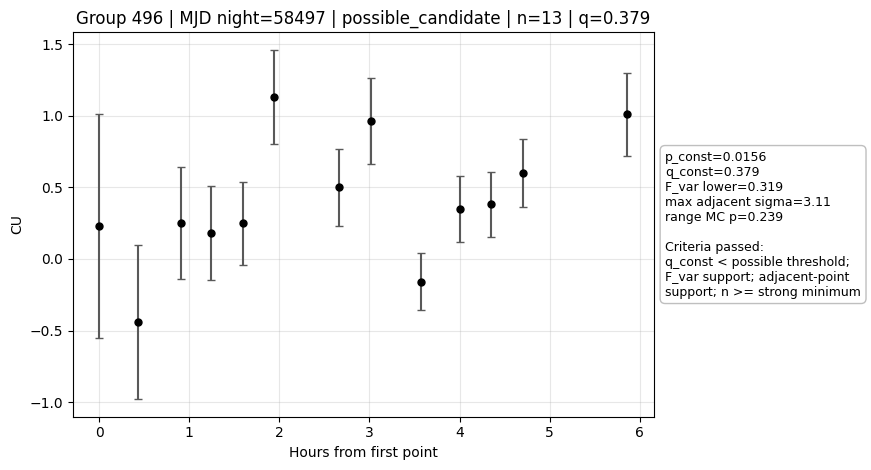

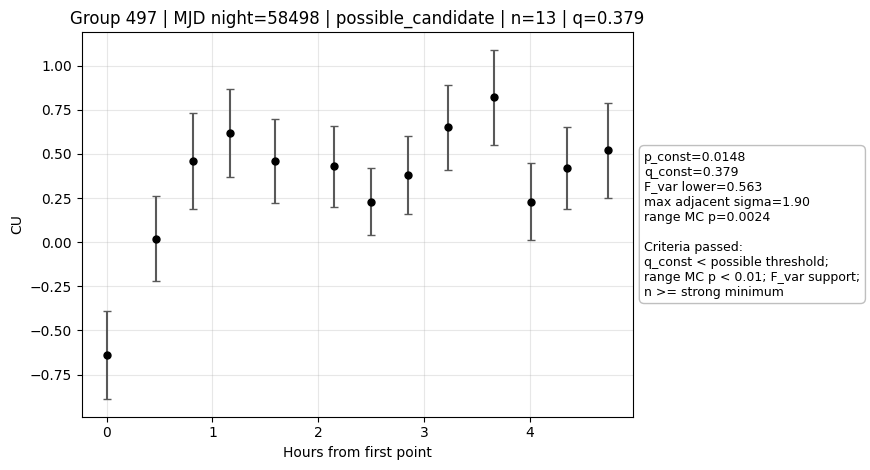

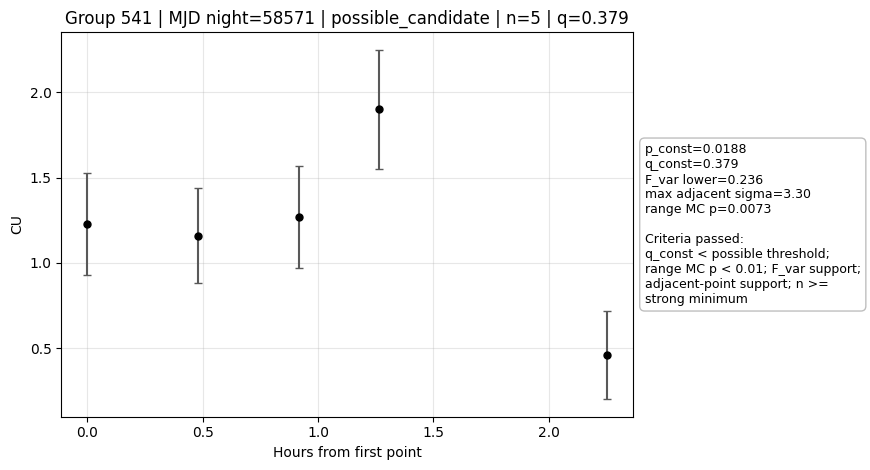

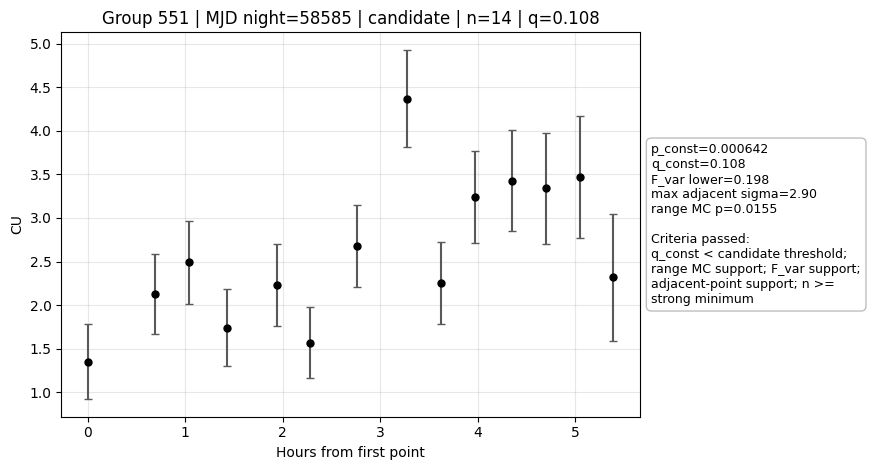

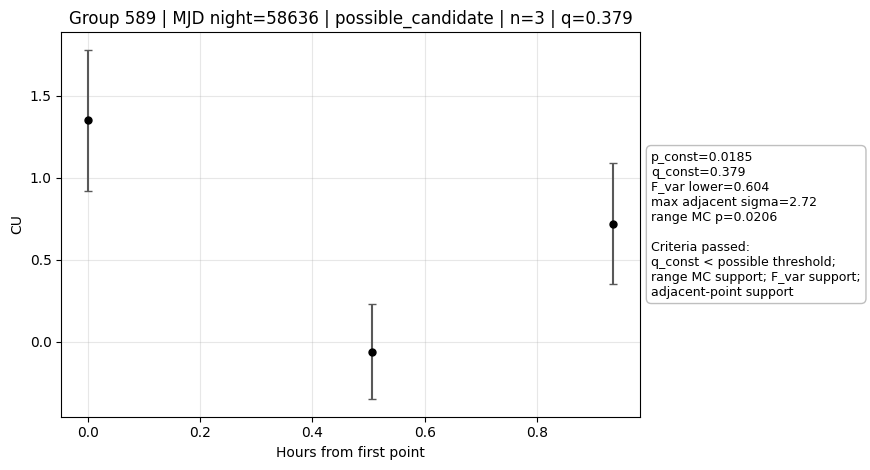

In [128]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plot_classes = ["strong_candidate", "candidate", "possible_candidate"]
df = (
    __daten421_20_mjdnight[
        __daten421_20_mjdnight["candidate_class"].isin(plot_classes)
    ]
    .sort_values(by="gruppe")
)

for i, row in df.iterrows():
    x = np.asarray(row["x_data"], dtype=float)
    y = np.asarray(row["y_data"], dtype=float)
    yerr = np.asarray(row["y_err_data"], dtype=float)
    x_hours = (x - np.nanmin(x)) * 24.0

    fig, ax = plt.subplots(figsize=(12, 4.8))

    ax.errorbar(
        x_hours,
        y,
        yerr=yerr,
        fmt="o",
        capsize=3,
        color="black",
        ecolor="0.35",
        markersize=5,
    )

    night_label = ""
    if "mjd_nacht" in row.index and np.isfinite(row["mjd_nacht"]):
        night_label = f" | MJD night={int(row['mjd_nacht'])}"

    ax.set_title(
        f"Group {int(row['gruppe'])}{night_label} | {row['candidate_class']} | "
        f"n={int(row['n'])} | q={row['q_const']:.3g}"
    )
    ax.set_xlabel("Hours from first point")
    ax.set_ylabel("CU")

    stats_text = (
        f"p_const={row['p_const']:.3g}\n"
        f"q_const={row['q_const']:.3g}\n"
        f"F_var lower={row['F_var_lower']:.3g}\n"
        f"max adjacent sigma={row['max_adjacent_sigma']:.2f}\n"
        f"range MC p={row['range_p_mc']:.3g}\n\n"
        "Criteria passed:\n"
        + textwrap.fill(str(row["candidate_criteria"]), width=34)
    )
    ax.text(
        1.02,
        0.5,
        stats_text,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "0.75"},
    )

    ax.grid(True, alpha=0.3)
    fig.tight_layout(rect=[0, 0, 0.74, 1])
    fig.savefig(f"figs/candidate{i}.png")
    plt.show()


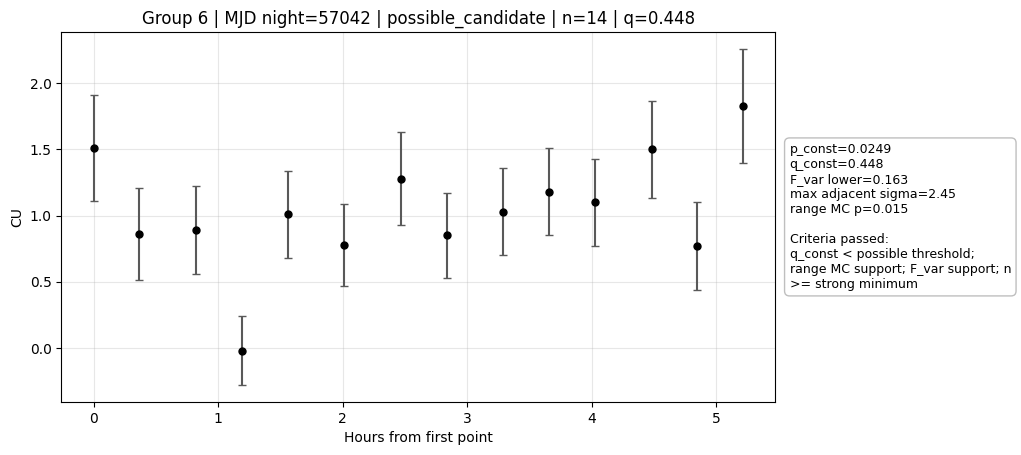

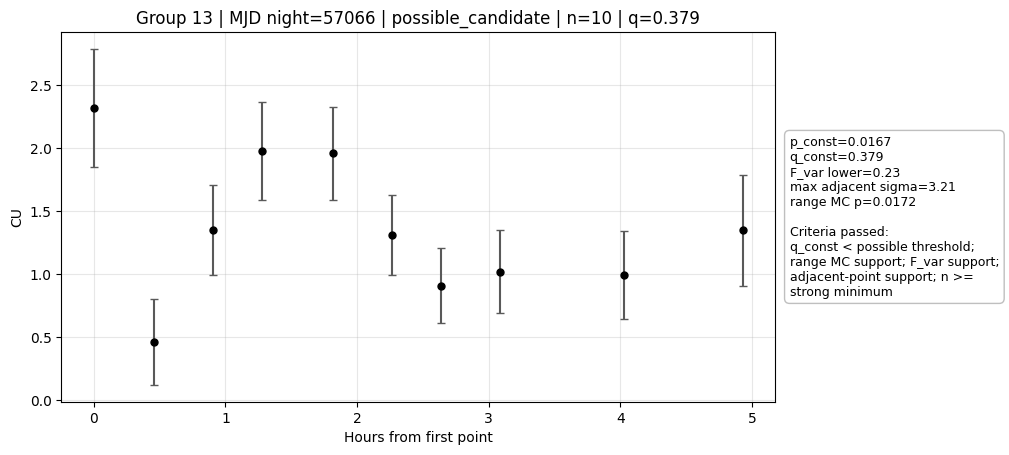

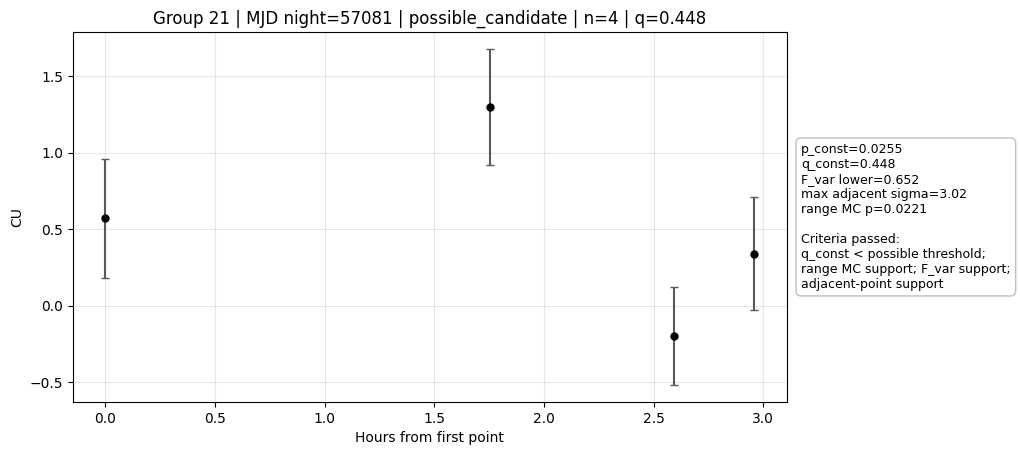

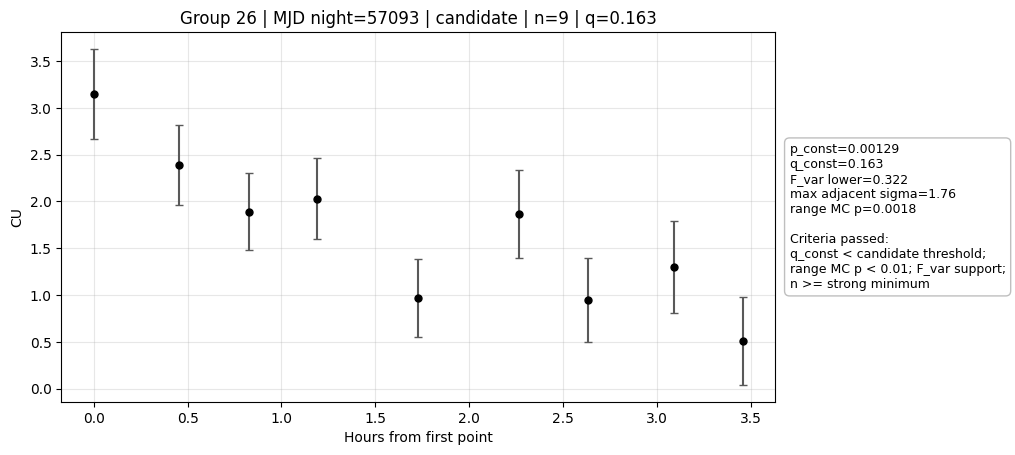

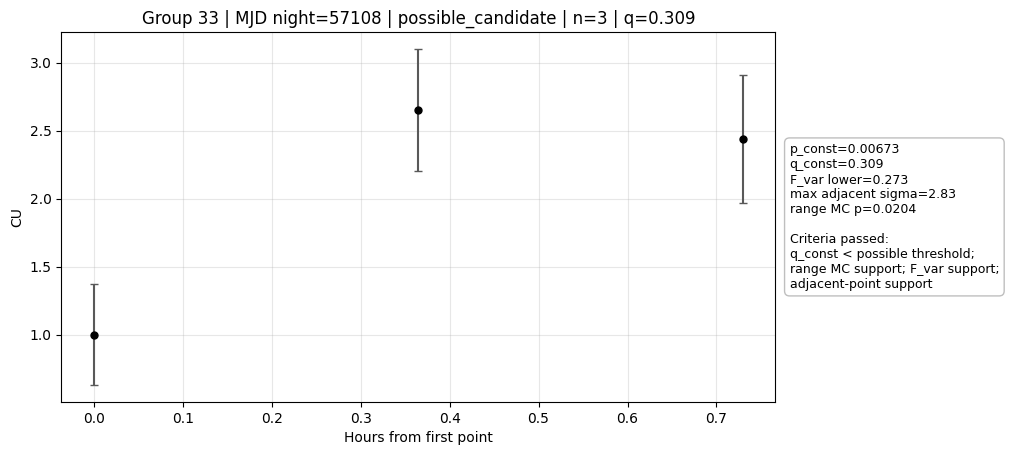

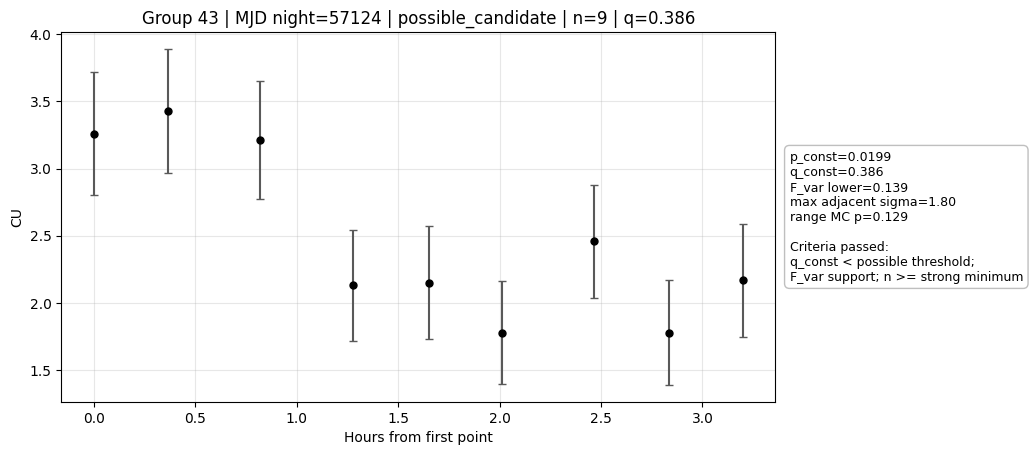

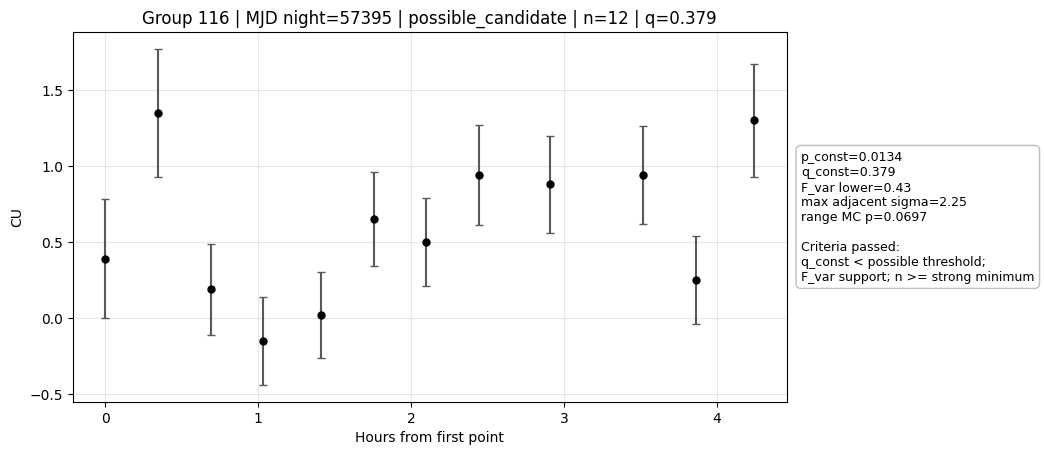

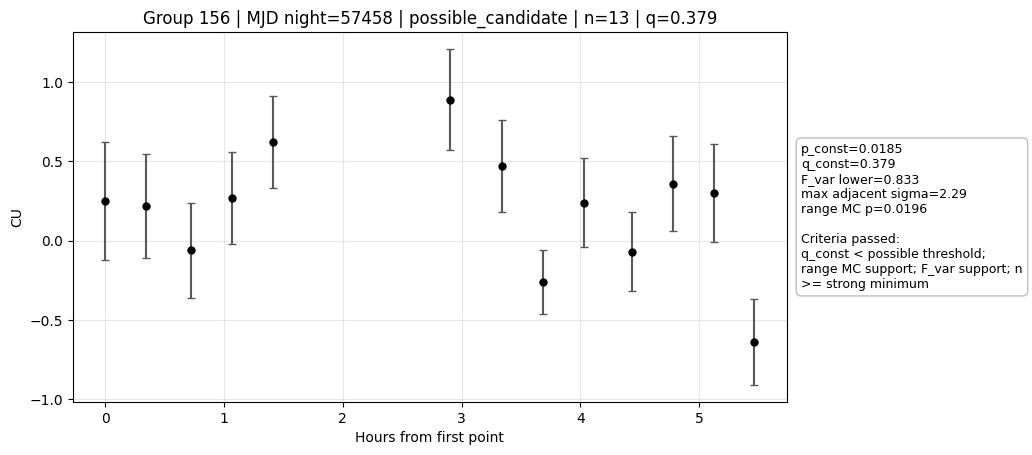

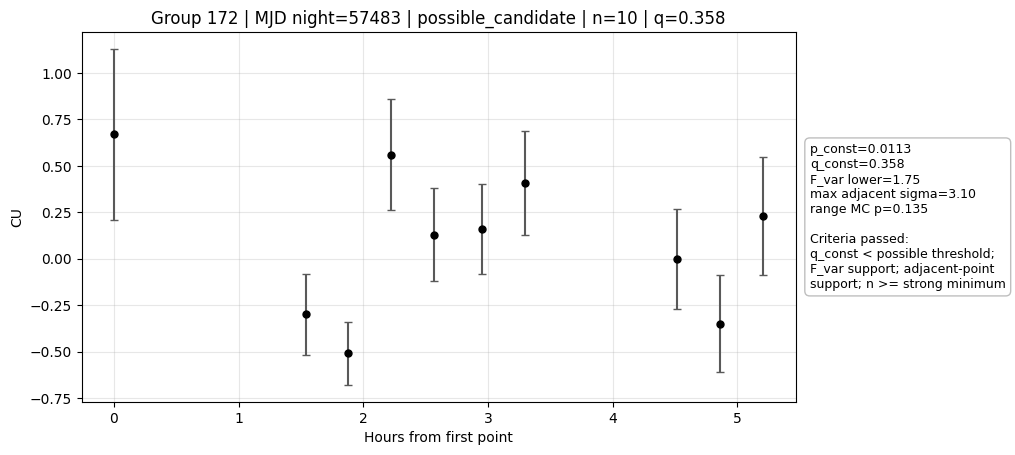

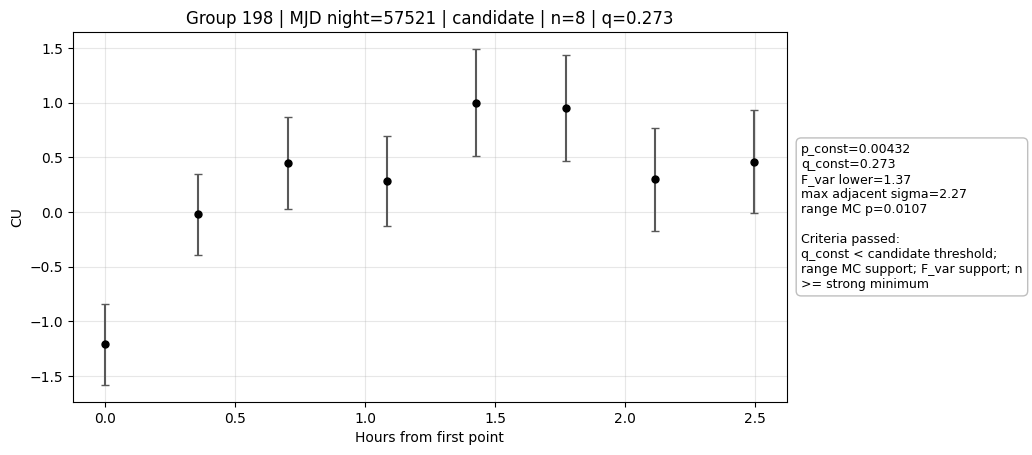

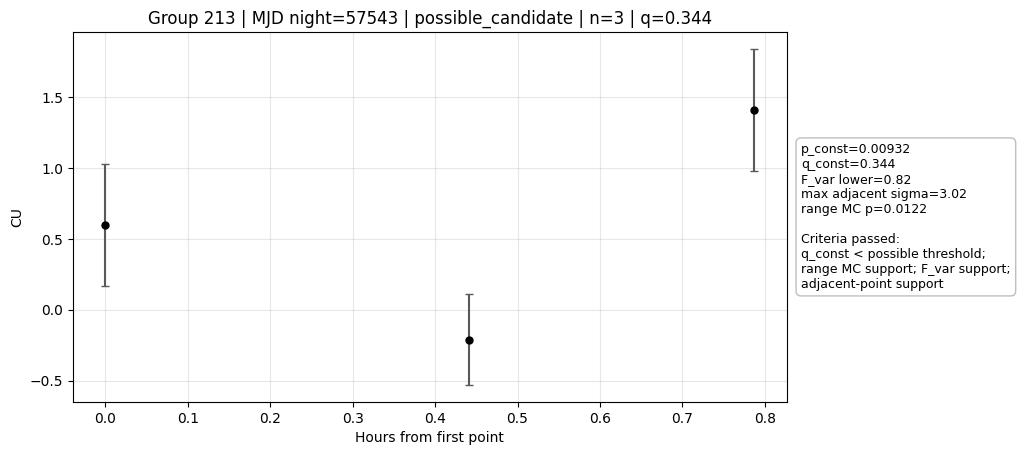

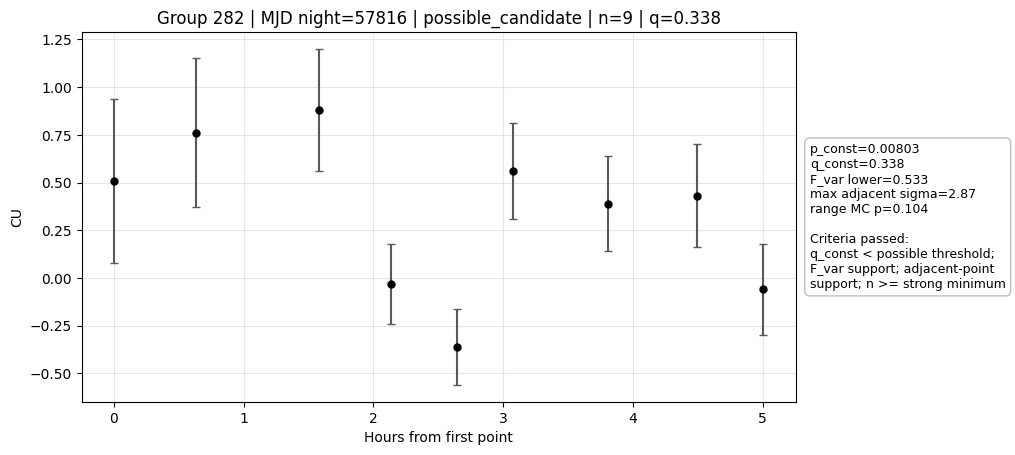

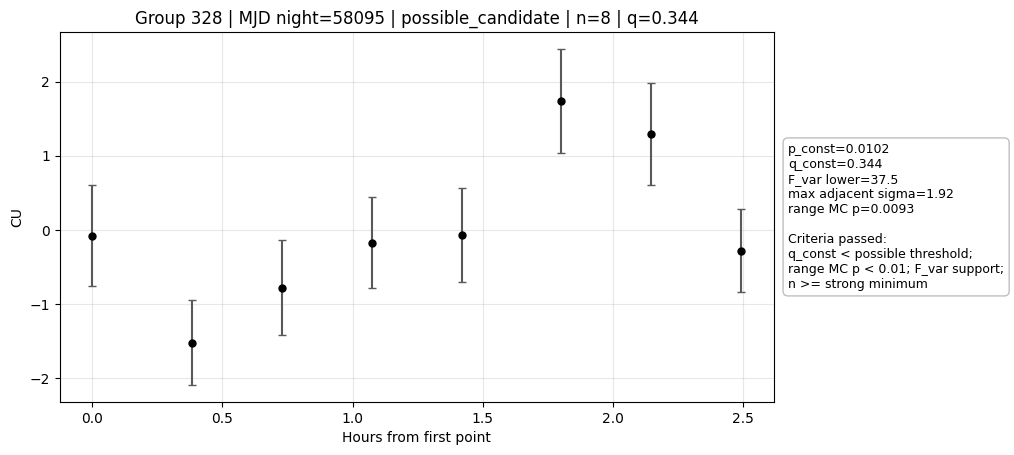

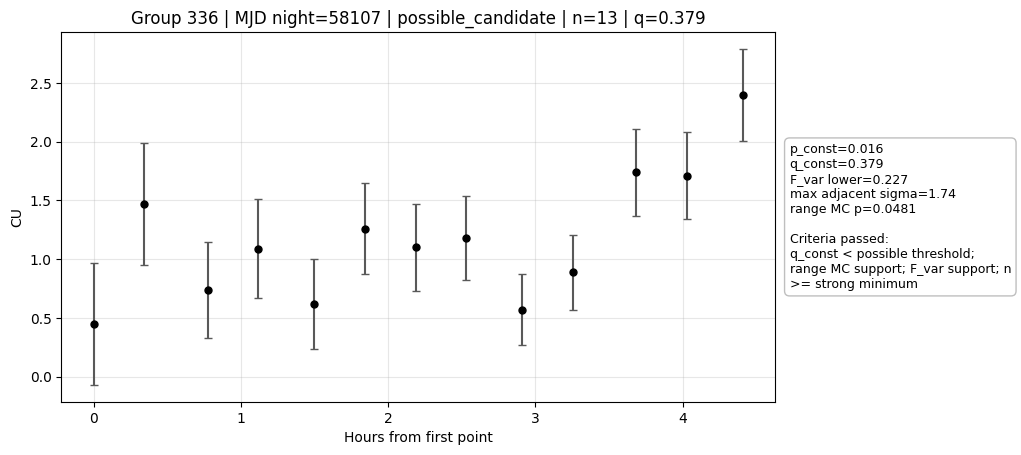

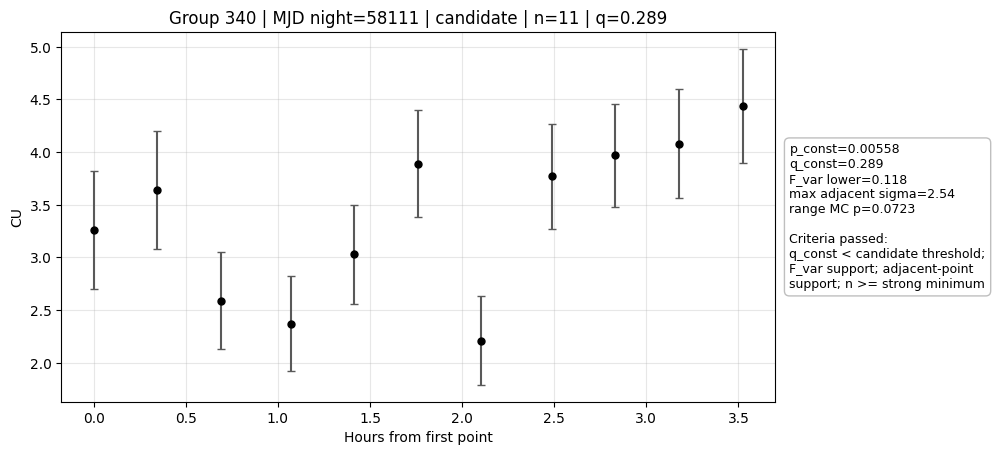

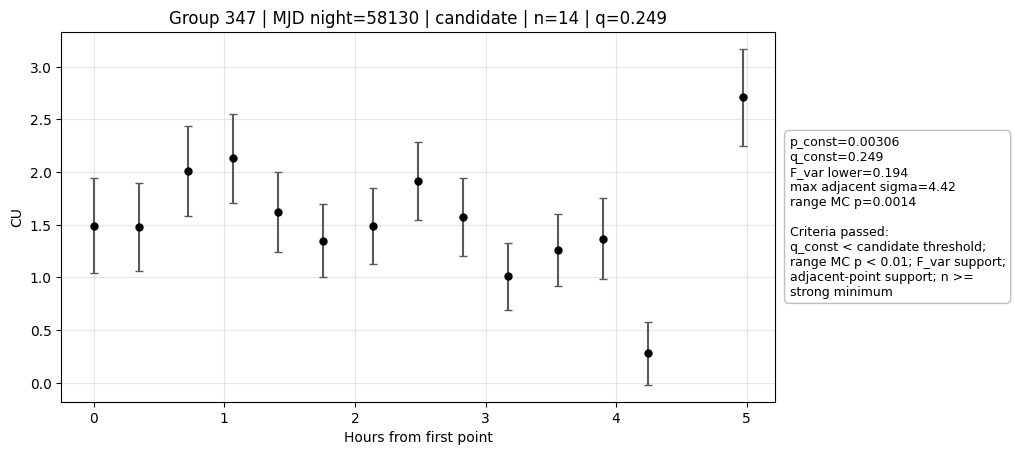

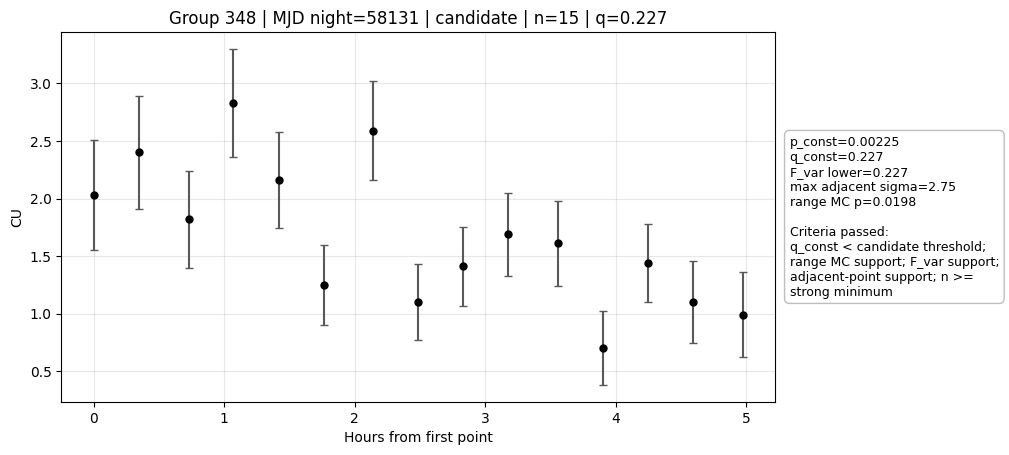

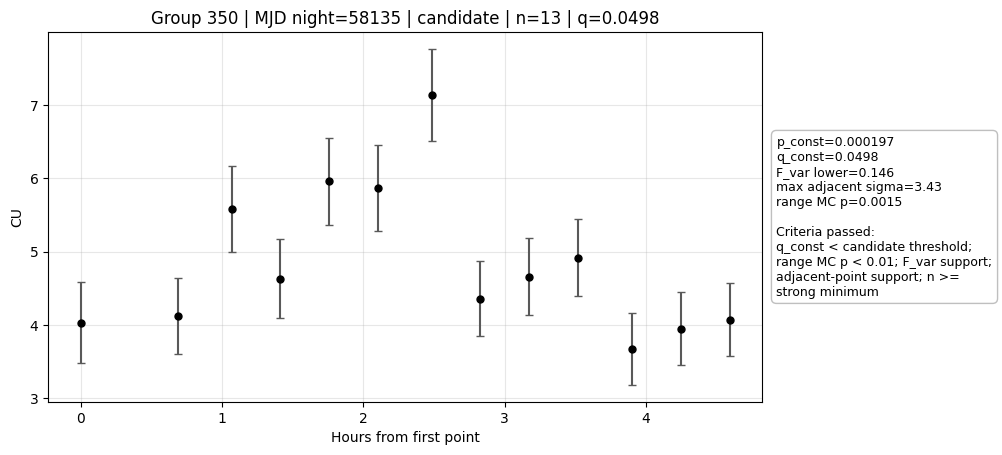

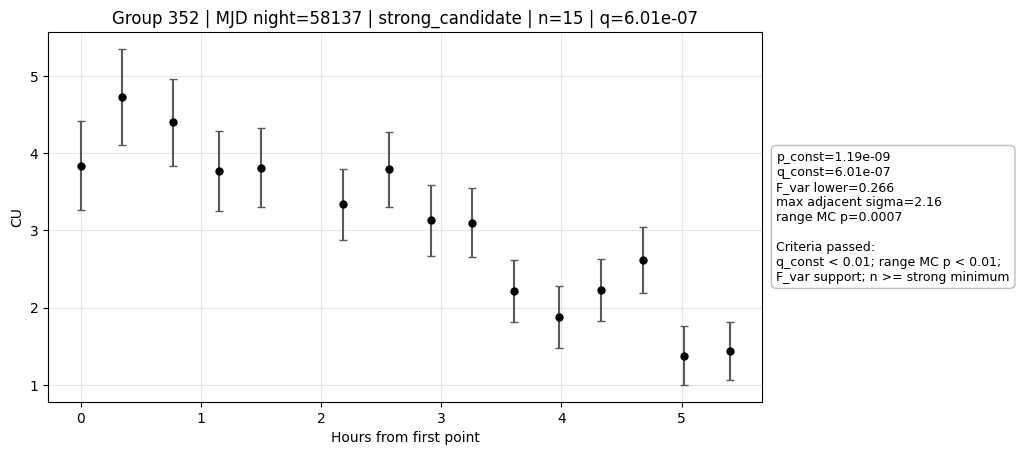

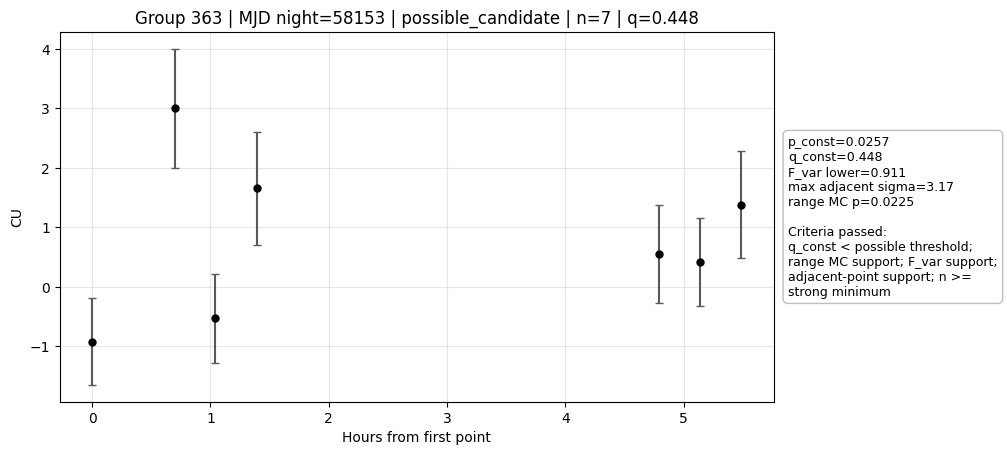

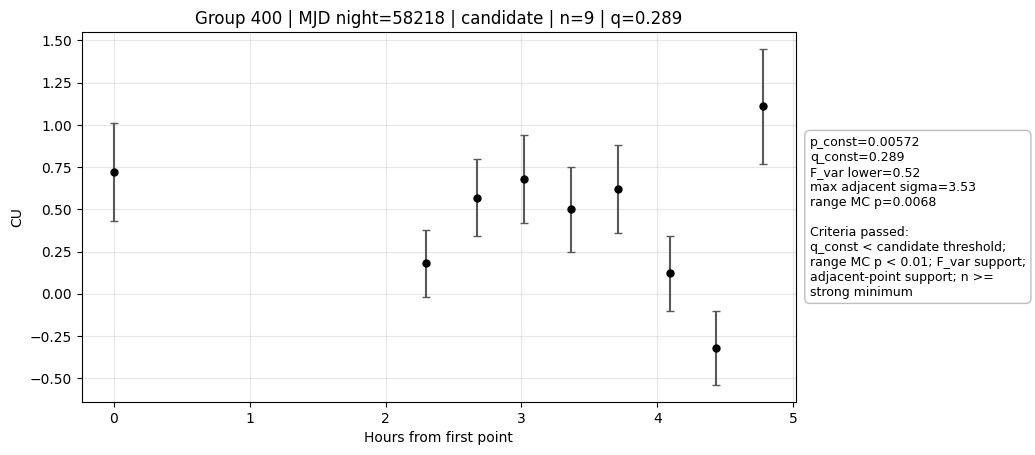

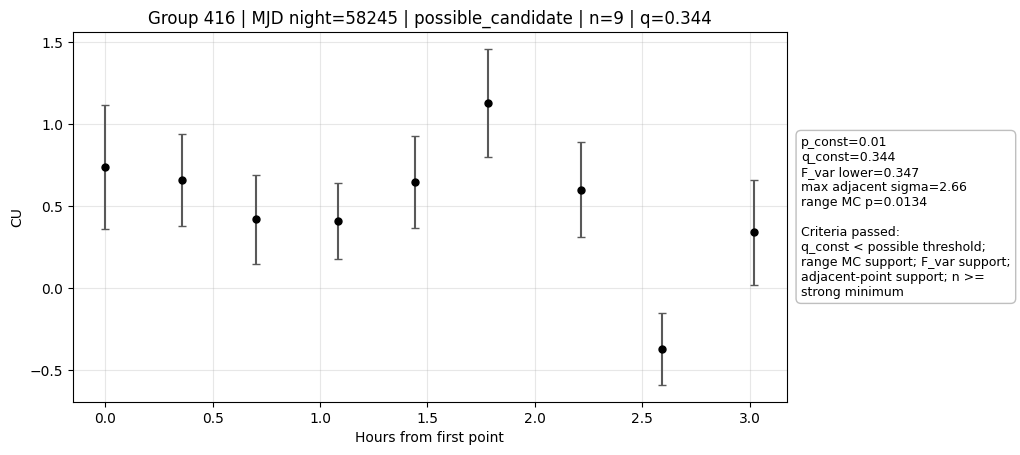

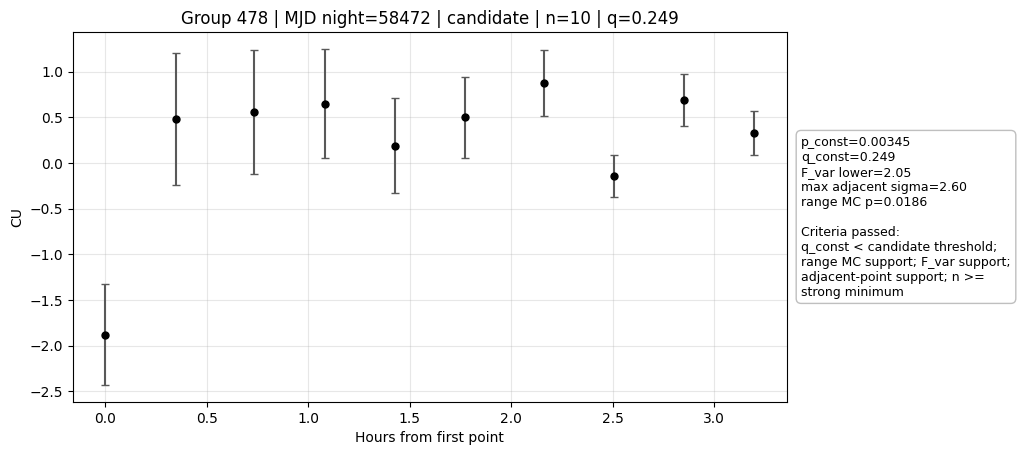

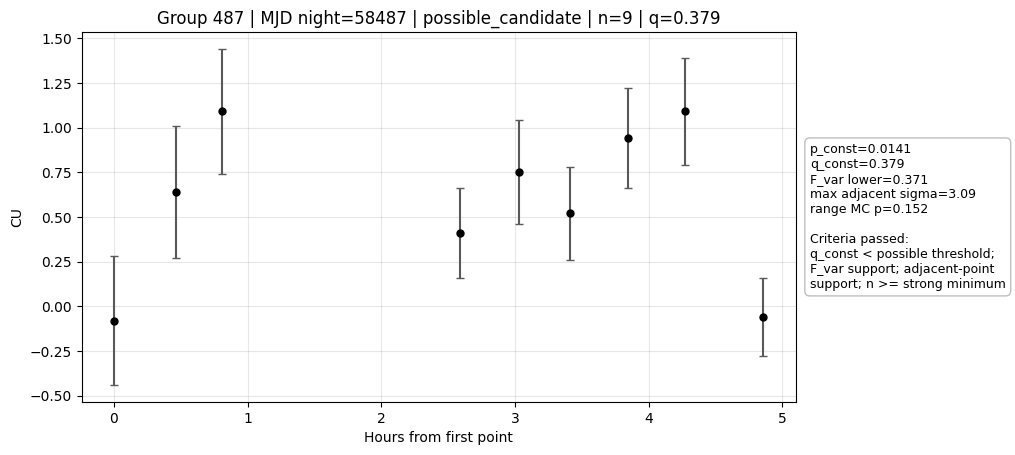

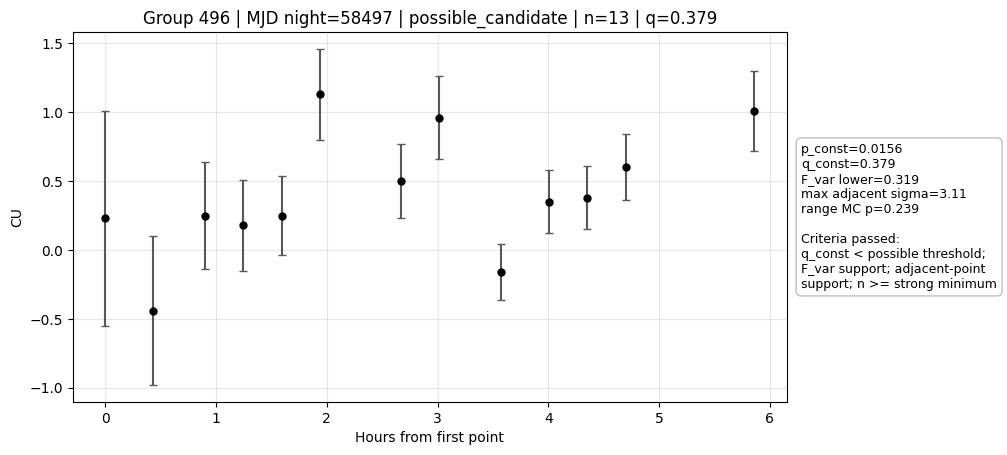

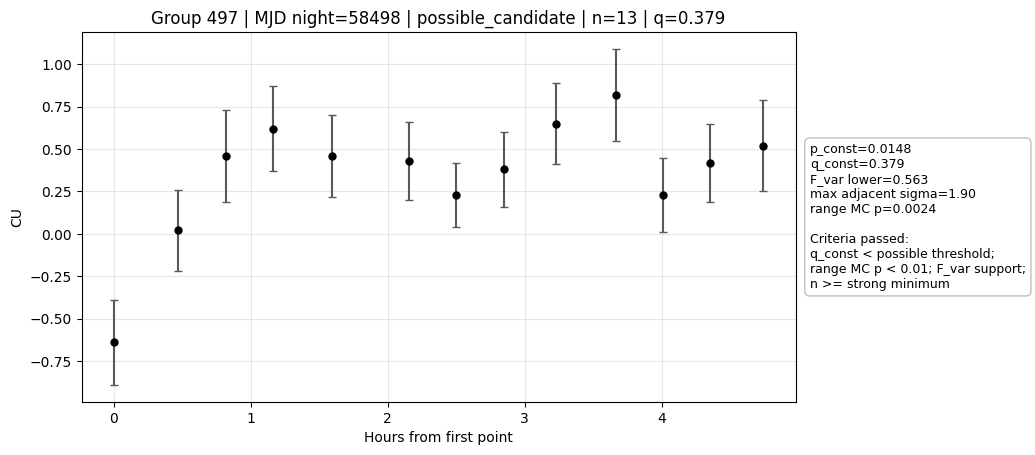

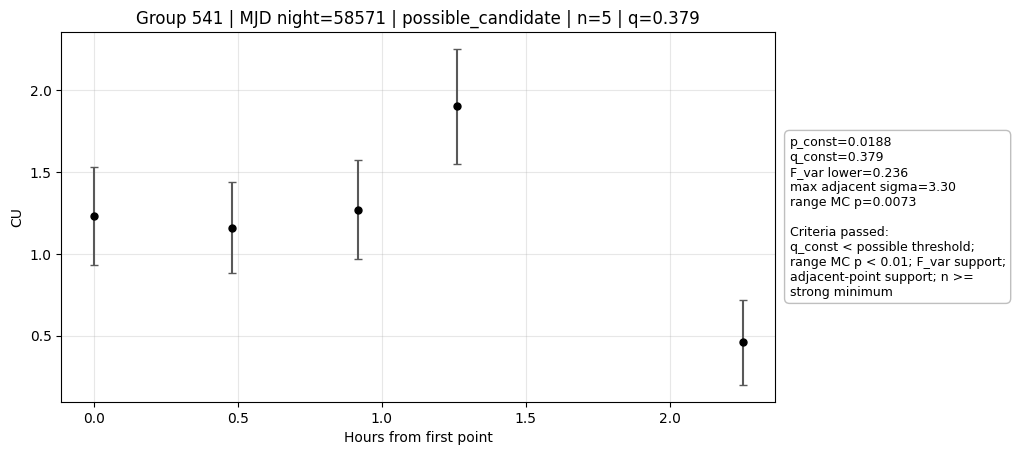

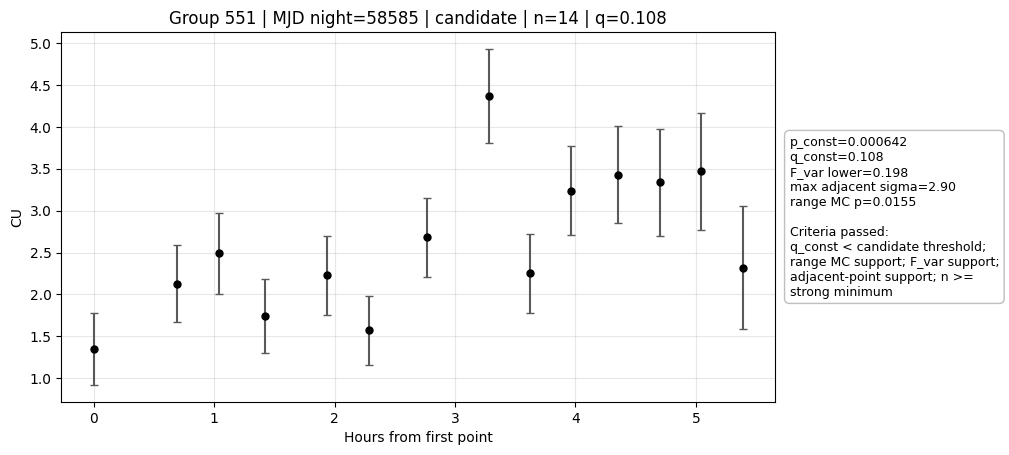

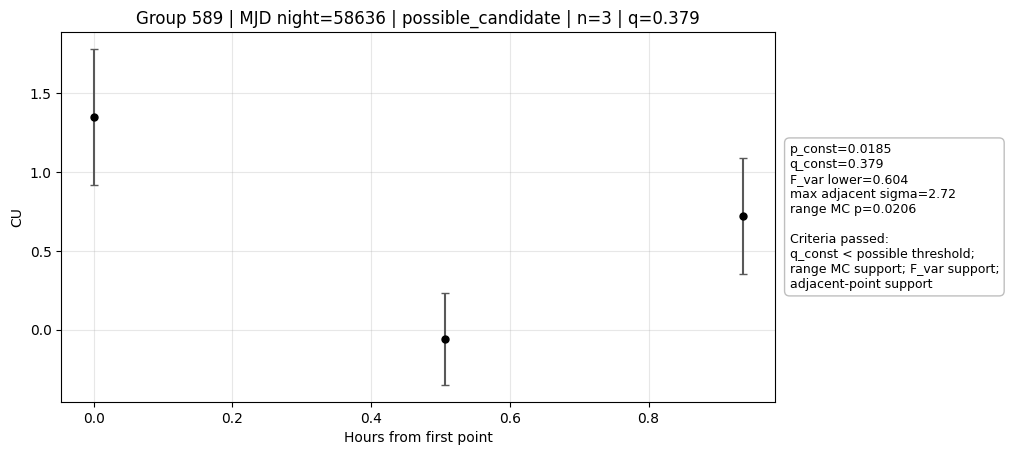

In [129]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plot_classes = ["strong_candidate", "candidate", "possible_candidate"]

df = (
    __daten421_20_mjdnight[
        __daten421_20_mjdnight["candidate_class"].isin(plot_classes)
    ]
    .sort_values(by="gruppe")
)

for i, row in df.iterrows():

    x = np.asarray(row["x_data"], dtype=float)
    y = np.asarray(row["y_data"], dtype=float)
    yerr = np.asarray(row["y_err_data"], dtype=float)

    x_hours = (x - np.nanmin(x)) * 24.0

    fig, ax = plt.subplots(figsize=(12, 4.8))

    ax.errorbar(
        x_hours,
        y,
        yerr=yerr,
        fmt="o",
        capsize=3,
        color="black",
        ecolor="0.35",
        markersize=5,
    )

    night_label = ""
    if "mjd_nacht" in row.index and np.isfinite(row["mjd_nacht"]):
        night_label = f" | MJD night={int(row['mjd_nacht'])}"

    ax.set_title(
        f"Group {int(row['gruppe'])}{night_label} | "
        f"{row['candidate_class']} | "
        f"n={int(row['n'])} | "
        f"q={row['q_const']:.3g}"
    )

    ax.set_xlabel("Hours from first point")
    ax.set_ylabel("CU")

    stats_text = (
        f"p_const={row['p_const']:.3g}\n"
        f"q_const={row['q_const']:.3g}\n"
        f"F_var lower={row['F_var_lower']:.3g}\n"
        f"max adjacent sigma={row['max_adjacent_sigma']:.2f}\n"
        f"range MC p={row['range_p_mc']:.3g}\n\n"
        "Criteria passed:\n"
        + textwrap.fill(
            str(row["candidate_criteria"]),
            width=34
        )
    )

    text_box = ax.text(
        1.02,
        0.5,
        stats_text,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "0.75",
        },
    )

    ax.grid(True, alpha=0.3)

    # reserve explicit room for the side text box
    fig.subplots_adjust(right=0.72)

    fig.savefig(
        f"figs/candidate{i}.png",
        dpi=150,
        bbox_inches="tight",
        bbox_extra_artists=[text_box],
        pad_inches=0.15,
    )

    plt.show()
    plt.close(fig)

### Zoom Bayesian-block flare candidates

Use the candidate rows from the last section as the outer selection, then run Bayesian blocks and HOP inside each selected group. The helper below plots only the HOP window plus padding, so the candidate nights can be inspected at flare scale.


In [123]:
from lightcurves.lc import LightCurve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _finite_candidate_arrays(row):
    """Return finite x/y/yerr arrays from a candidate-result row."""
    x = np.asarray(row["x_data"], dtype=float)
    y = np.asarray(row["y_data"], dtype=float)
    yerr = np.asarray(row["y_err_data"], dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    order = np.argsort(x[mask])
    return x[mask][order], y[mask][order], yerr[mask][order]


def _candidate_label(row):
    night_label = ""
    if "mjd_nacht" in row.index and pd.notna(row["mjd_nacht"]):
        night_label = f" | MJD night={int(row['mjd_nacht'])}"
    return (
        f"Group {int(row['gruppe'])}{night_label} | {row['candidate_class']} | "
        f"n={int(row['n'])} | q={row['q_const']:.3g}"
    )


def build_full_bblock_lightcurve(
    data,
    time_col="MJD",
    flux_col="CU",
    err_col="CU_err",
    p0_value=0.05,
    hop_method="baseline",
):
    """Build Bayesian blocks and HOPs from the full light curve table."""
    x = np.asarray(data[time_col], dtype=float)
    y = np.asarray(data[flux_col], dtype=float)
    yerr = np.asarray(data[err_col], dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    order = np.argsort(x[mask])

    lc = LightCurve(x[mask][order], y[mask][order], yerr[mask][order])
    lc.get_bblocks(p0_value=p0_value)
    hops = lc.find_hop(hop_method)
    return lc, hops


def summarize_candidate_hop_overlaps(
    candidate_df,
    hops,
    classes=("strong_candidate", "candidate", "possible_candidate"),
    min_overlap_hours=0.0,
):
    """Match full-light-curve HOP intervals against candidate groups by time overlap."""
    rows = []
    selected = candidate_df[candidate_df["candidate_class"].isin(classes)].sort_values("gruppe")
    min_overlap_days = min_overlap_hours / 24.0

    for _, row in selected.iterrows():
        x, _, _ = _finite_candidate_arrays(row)
        group_start = float(np.nanmin(x))
        group_end = float(np.nanmax(x))
        matched = False

        for hop_index, hop in enumerate(hops):
            hop_start = float(hop.start_time)
            hop_peak = float(hop.peak_time)
            hop_end = float(hop.end_time)
            overlap = max(0.0, min(group_end, hop_end) - max(group_start, hop_start))
            peak_in_group = group_start <= hop_peak <= group_end

            if overlap <= min_overlap_days and not peak_in_group:
                continue

            matched = True
            rows.append({
                "gruppe": int(row["gruppe"]),
                "candidate_class": row["candidate_class"],
                "q_const": row["q_const"],
                "n": int(row["n"]),
                "group_start_mjd": group_start,
                "group_end_mjd": group_end,
                "hop_index": hop_index,
                "hop_start_mjd": hop_start,
                "hop_peak_mjd": hop_peak,
                "hop_end_mjd": hop_end,
                "overlap_hours": overlap * 24.0,
                "peak_in_group": peak_in_group,
                "hop_duration_hours": float(hop.dur) * 24.0,
                "rise_hours": float(hop.rise_time) * 24.0,
                "decay_hours": float(hop.decay_time) * 24.0,
                "peak_flux": float(hop.peak_flux),
            })

        if not matched:
            rows.append({
                "gruppe": int(row["gruppe"]),
                "candidate_class": row["candidate_class"],
                "q_const": row["q_const"],
                "n": int(row["n"]),
                "group_start_mjd": group_start,
                "group_end_mjd": group_end,
                "hop_index": np.nan,
                "hop_start_mjd": np.nan,
                "hop_peak_mjd": np.nan,
                "hop_end_mjd": np.nan,
                "overlap_hours": 0.0,
                "peak_in_group": False,
                "hop_duration_hours": np.nan,
                "rise_hours": np.nan,
                "decay_hours": np.nan,
                "peak_flux": np.nan,
            })

    return pd.DataFrame(rows)


def plot_candidate_hop_overlaps(
    candidate_df,
    full_lc,
    hops,
    classes=("strong_candidate", "candidate", "possible_candidate"),
    min_overlap_hours=0.0,
    pad_frac=0.25,
    min_pad_hours=4.0,
    max_plots=None,
):
    """Plot full-light-curve Bayesian blocks around HOPs that overlap candidate groups."""
    matches = summarize_candidate_hop_overlaps(
        candidate_df,
        hops,
        classes=classes,
        min_overlap_hours=min_overlap_hours,
    )
    matches_to_plot = matches[matches["hop_index"].notna()].sort_values(["gruppe", "hop_index"])
    plotted = 0

    for _, match in matches_to_plot.iterrows():
        if max_plots is not None and plotted >= max_plots:
            break

        row = candidate_df.loc[candidate_df["gruppe"] == match["gruppe"]].iloc[0]
        cx, cy, cyerr = _finite_candidate_arrays(row)
        hop = hops[int(match["hop_index"])]
        hop_start = float(hop.start_time)
        hop_peak = float(hop.peak_time)
        hop_end = float(hop.end_time)
        hop_duration = max(hop_end - hop_start, 0.0)
        pad_days = max(min_pad_hours / 24.0, pad_frac * hop_duration)
        xlim = (hop_start - pad_days, hop_end + pad_days)
        x0 = xlim[0]

        full_mask = (full_lc.time >= xlim[0]) & (full_lc.time <= xlim[1])
        cand_mask = (cx >= xlim[0]) & (cx <= xlim[1])

        fig, ax = plt.subplots(figsize=(12, 4.8))
        ax.errorbar(
            (full_lc.time[full_mask] - x0) * 24.0,
            full_lc.flux[full_mask],
            yerr=full_lc.flux_error[full_mask],
            fmt="o",
            capsize=3,
            color="0.55",
            ecolor="0.75",
            markersize=4,
            label="full 20 min data",
        )
        ax.step(
            (full_lc.time[full_mask] - x0) * 24.0,
            full_lc.block_pbin[full_mask],
            where="mid",
            color="tab:blue",
            linewidth=1.8,
            label="full-light-curve Bayesian blocks",
        )
        ax.errorbar(
            (cx[cand_mask] - x0) * 24.0,
            cy[cand_mask],
            yerr=cyerr[cand_mask],
            fmt="o",
            capsize=3,
            color="black",
            ecolor="0.25",
            markersize=5,
            label="matched candidate group",
        )
        ax.axvspan((hop_start - x0) * 24.0, (hop_end - x0) * 24.0, color="tab:orange", alpha=0.18, label="HOP interval")
        ax.axvline((hop_peak - x0) * 24.0, color="tab:red", linestyle=":", linewidth=1.5, label="HOP peak")
        ax.axvspan((match["group_start_mjd"] - x0) * 24.0, (match["group_end_mjd"] - x0) * 24.0, color="tab:green", alpha=0.10, label="candidate group span")

        ax.set_xlabel(f"Hours from MJD {x0:.5f}")
        ax.set_ylabel("CU")
        ax.set_title(
            f"{_candidate_label(row)}\n"
            f"HOP {int(match['hop_index'])}: {hop_start:.5f}-{hop_end:.5f} MJD | "
            f"overlap={match['overlap_hours']:.2f} h | peak_in_group={bool(match['peak_in_group'])}"
        )
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        fig.tight_layout()
        plt.show()
        plotted += 1

    print(f"Plotted {plotted} of {len(matches_to_plot)} matched candidate/HOP overlaps.")
    return matches


def lightcurve_and_hops_from_candidate(row, p0_value=0.05, hop_method="baseline"):
    """Build a LightCurve from one candidate row and return its Bayesian-block HOPs."""
    x, y, yerr = _finite_candidate_arrays(row)
    lc = LightCurve(x, y, yerr)
    lc.get_bblocks(p0_value=p0_value)
    hops = lc.find_hop(hop_method)
    return lc, hops


def summarize_candidate_bblocks(
    candidate_df,
    classes=("strong_candidate", "candidate", "possible_candidate"),
    p0_value=0.05,
    hop_method="baseline",
):
    """Summarize Bayesian-block HOP windows found after recomputing inside each candidate group."""
    rows = []
    selected = candidate_df[candidate_df["candidate_class"].isin(classes)].sort_values("gruppe")

    for _, row in selected.iterrows():
        lc, hops = lightcurve_and_hops_from_candidate(row, p0_value=p0_value, hop_method=hop_method)
        group_start = float(np.nanmin(lc.time))
        group_end = float(np.nanmax(lc.time))

        if not hops:
            rows.append({
                "gruppe": int(row["gruppe"]),
                "candidate_class": row["candidate_class"],
                "q_const": row["q_const"],
                "n": int(row["n"]),
                "n_blocks": len(getattr(lc, "block_val", [])),
                "hop_index": np.nan,
                "hop_start_mjd": np.nan,
                "hop_peak_mjd": np.nan,
                "hop_end_mjd": np.nan,
                "hop_duration_hours": np.nan,
                "group_start_mjd": group_start,
                "group_end_mjd": group_end,
            })
            continue

        for hop_index, hop in enumerate(hops):
            rows.append({
                "gruppe": int(row["gruppe"]),
                "candidate_class": row["candidate_class"],
                "q_const": row["q_const"],
                "n": int(row["n"]),
                "n_blocks": len(getattr(lc, "block_val", [])),
                "hop_index": hop_index,
                "hop_start_mjd": float(hop.start_time),
                "hop_peak_mjd": float(hop.peak_time),
                "hop_end_mjd": float(hop.end_time),
                "hop_duration_hours": float(hop.dur) * 24.0,
                "rise_hours": float(hop.rise_time) * 24.0,
                "decay_hours": float(hop.decay_time) * 24.0,
                "peak_flux": float(hop.peak_flux),
                "group_start_mjd": group_start,
                "group_end_mjd": group_end,
            })

    return pd.DataFrame(rows)


Full light curve: 5109 points, 108 Bayesian blocks, 25 baseline HOPs
Matched candidate/HOP overlaps: 15


,gruppe,candidate_class,q_const,n,group_start_mjd,group_end_mjd,hop_index,hop_start_mjd,hop_peak_mjd,hop_end_mjd,overlap_hours,peak_in_group,hop_duration_hours,rise_hours,decay_hours,peak_flux
0,6,possible_candidate,4.481081e-01,14,57042.0562,57042.2734,0.0,57039.18675,57044.187300,57049.18785,5.2128,False,240.0264,120.0132,120.0132,1.058085
1,13,possible_candidate,3.793552e-01,10,57065.9866,57066.1920,1.0,57065.02030,57065.554525,57068.16820,4.9296,False,75.5496,12.8214,62.7282,1.595714
2,21,possible_candidate,4.481081e-01,4,57081.0719,57081.1952,NaN,NaN,NaN,NaN,0.0000,False,NaN,NaN,NaN,NaN
3,26,candidate,1.627103e-01,9,57092.9817,57093.1258,2.0,57087.14420,57095.079475,57096.09155,3.4584,False,214.7364,190.4466,24.2898,2.037222
4,33,possible_candidate,3.087546e-01,3,57108.0651,57108.0955,3.0,57108.07270,57111.495950,57112.48830,0.5472,False,105.9744,82.1580,23.8164,3.206000
5,43,possible_candidate,3.862609e-01,9,57123.9084,57124.0417,4.0,57121.93085,57123.719050,57125.50500,3.1992,False,85.7796,42.9168,42.8628,3.300000
6,116,possible_candidate,3.793552e-01,12,57395.0880,57395.2649,8.0,57385.19890,57386.711525,57408.08760,4.2456,False,549.3288,36.3030,513.0258,1.810541
7,156,possible_candidate,3.793552e-01,13,57457.9111,57458.1389,NaN,NaN,NaN,NaN,0.0000,False,NaN,NaN,NaN,NaN
8,172,possible_candidate,3.579698e-01,10,57482.8516,57483.0685,NaN,NaN,NaN,NaN,0.0000,False,NaN,NaN,NaN,NaN
9,198,candidate,2.726736e-01,8,57520.8689,57520.9730,NaN,NaN,NaN,NaN,0.0000,False,NaN,NaN,NaN,NaN


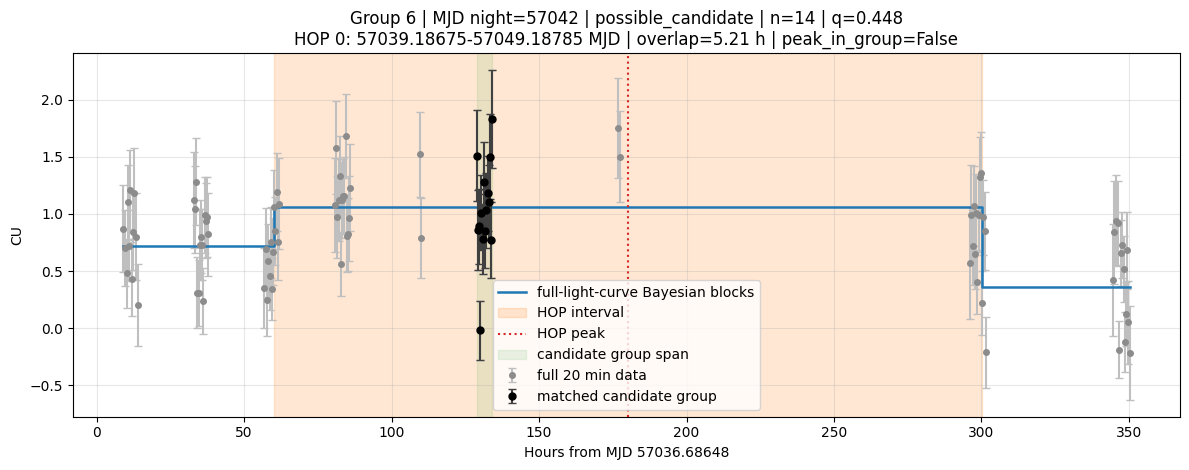

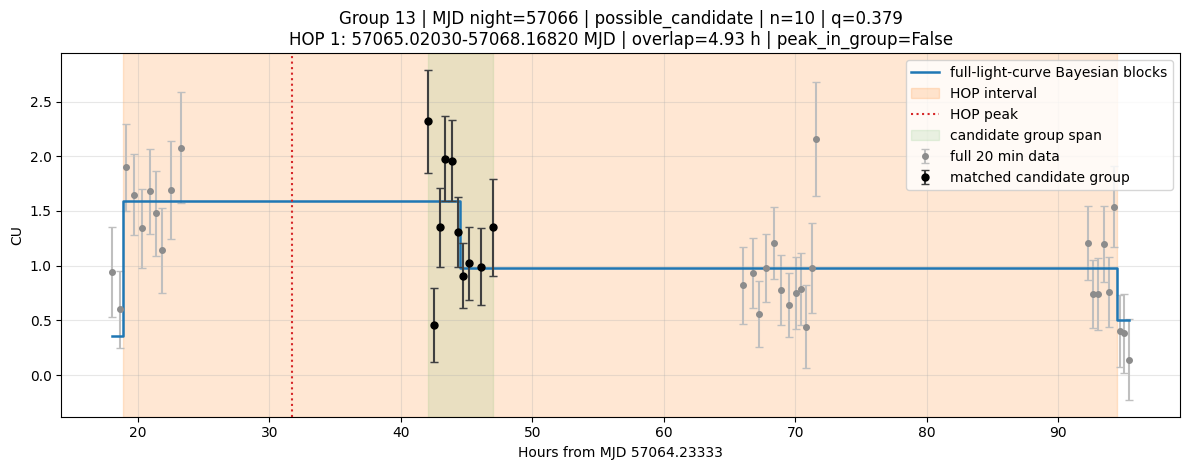

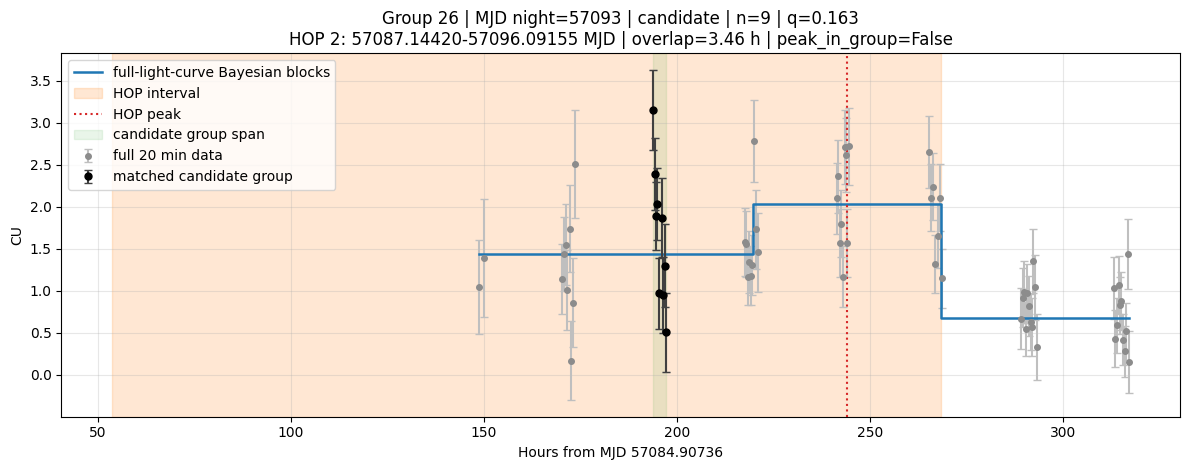

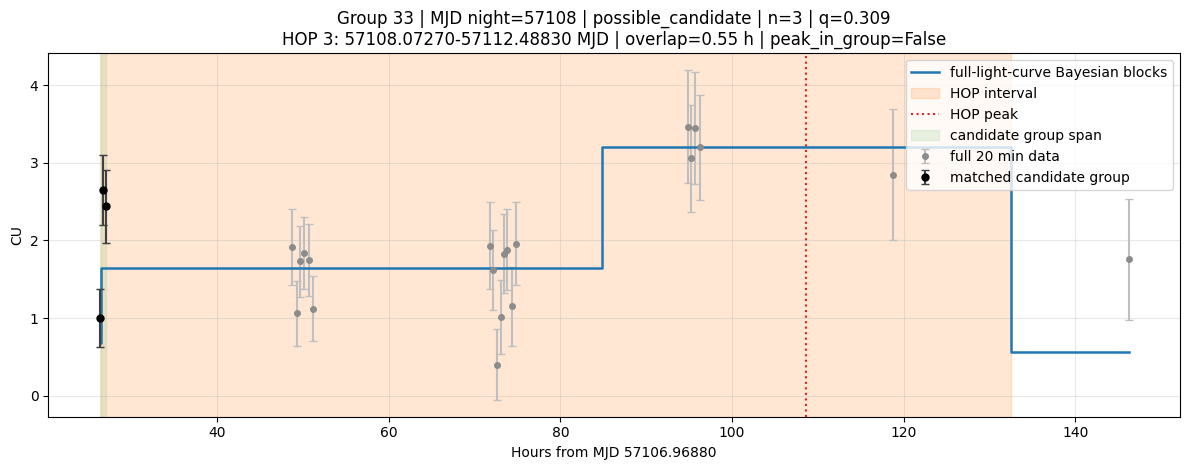

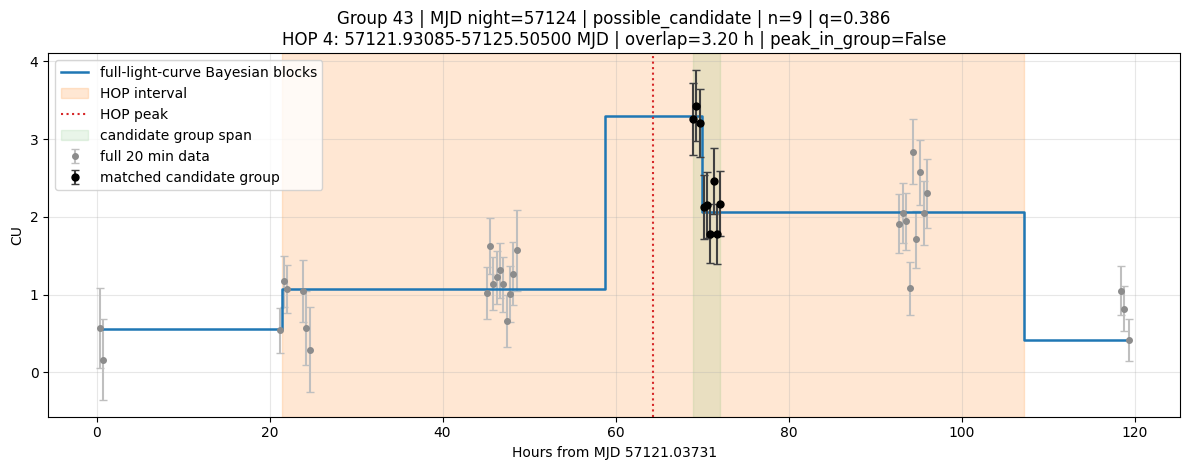

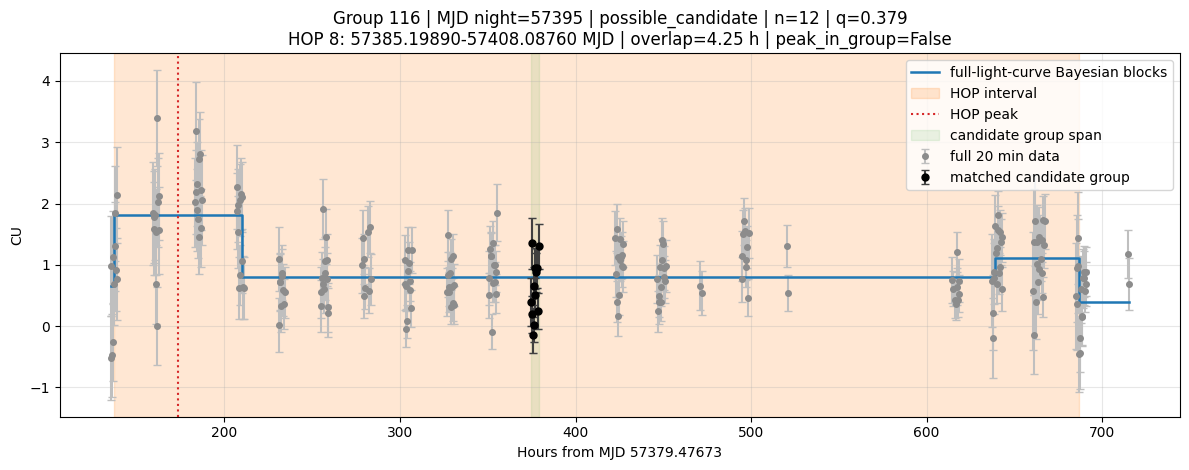

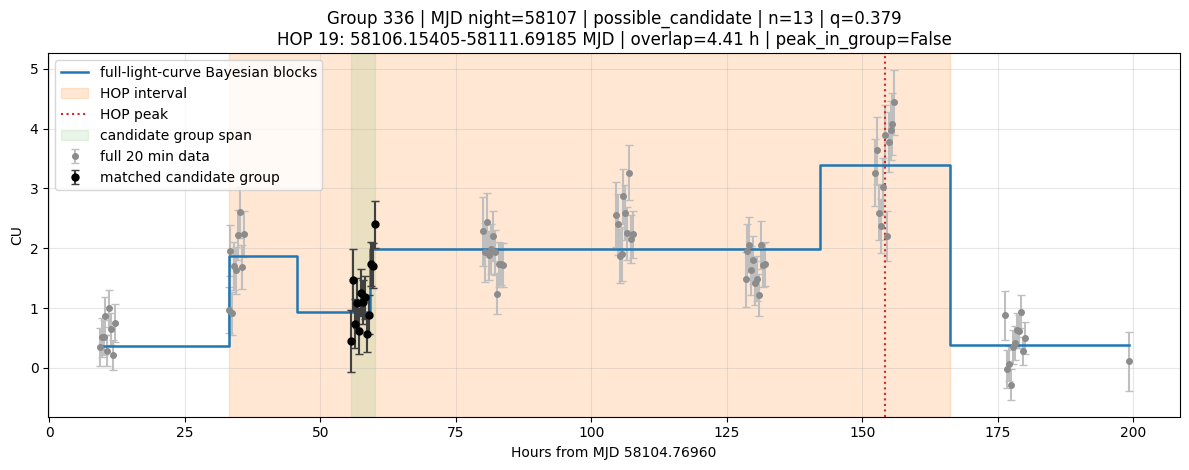

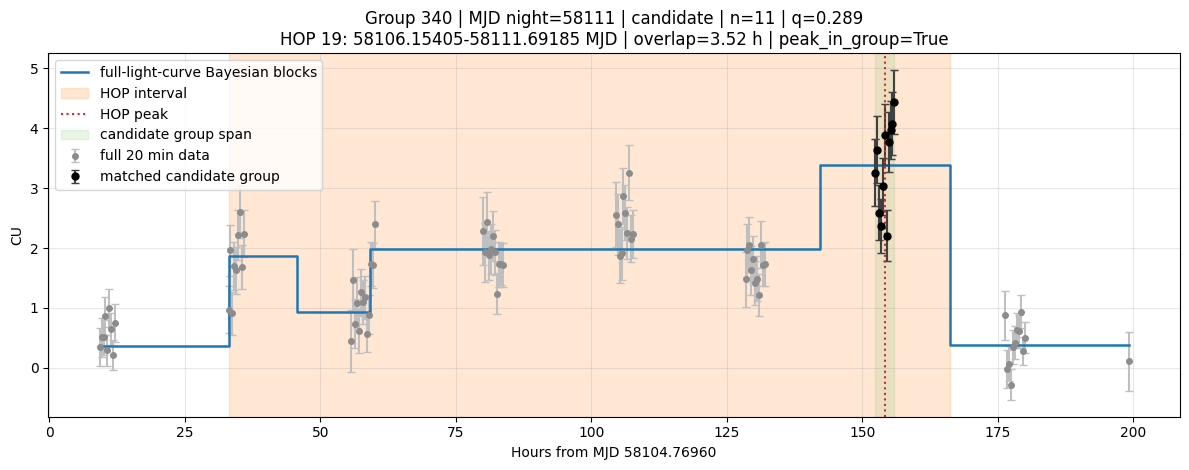

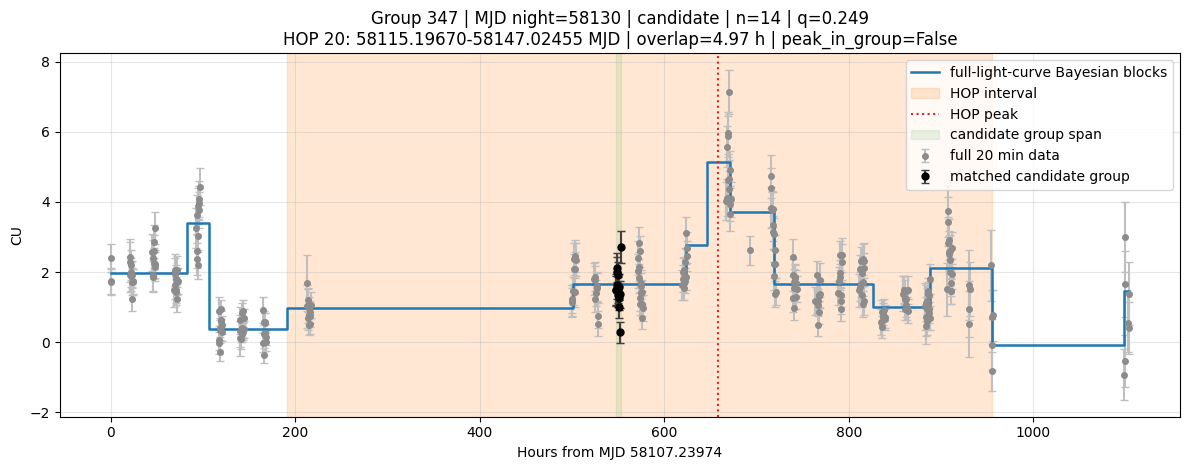

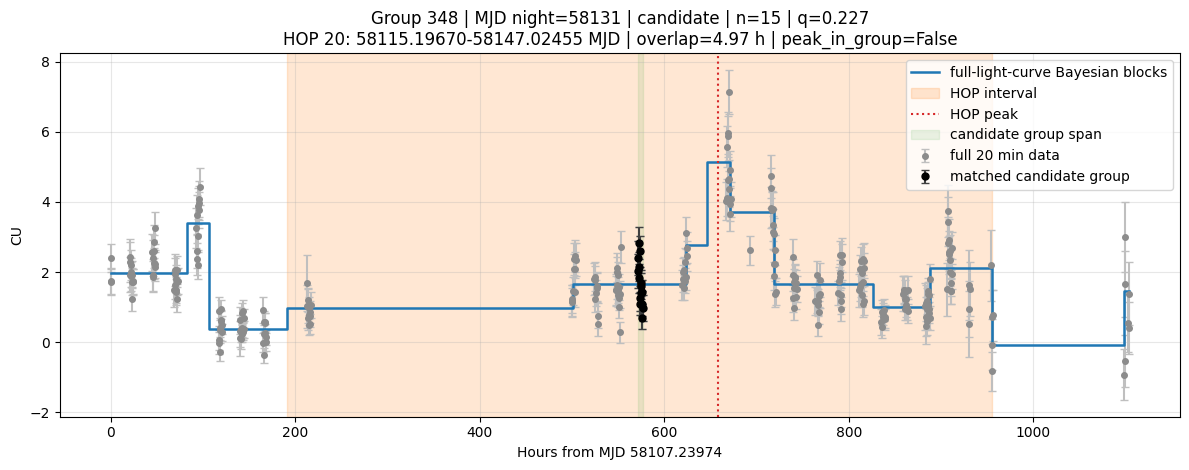

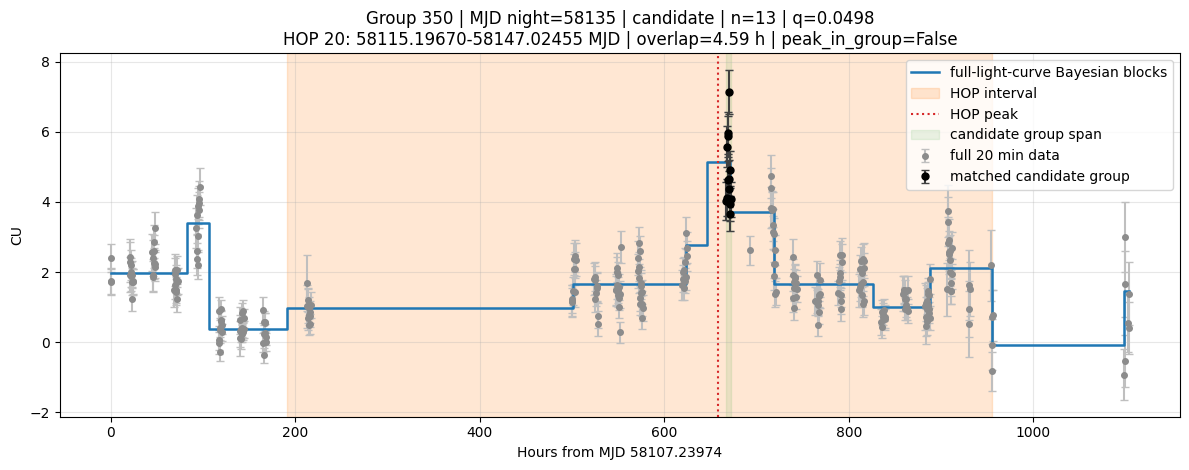

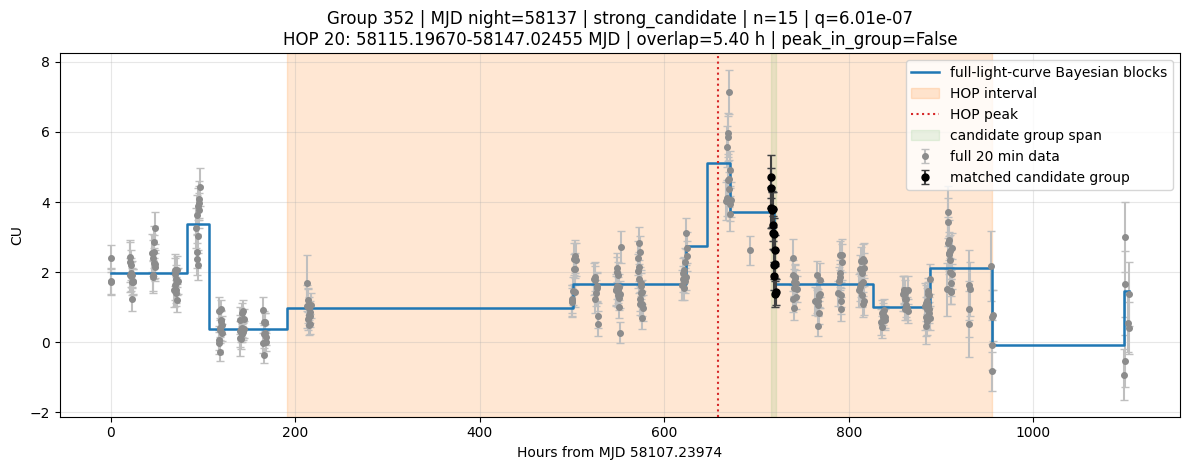

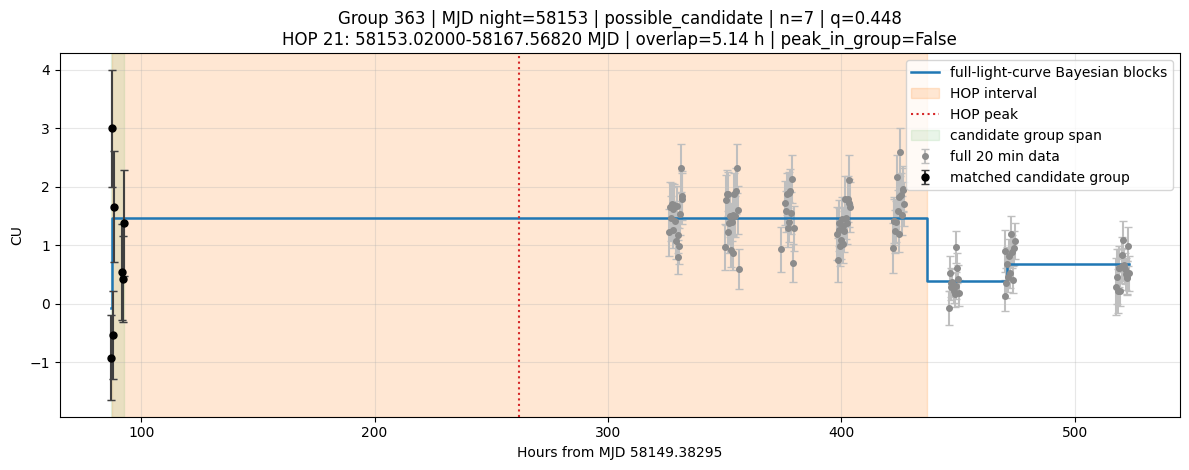

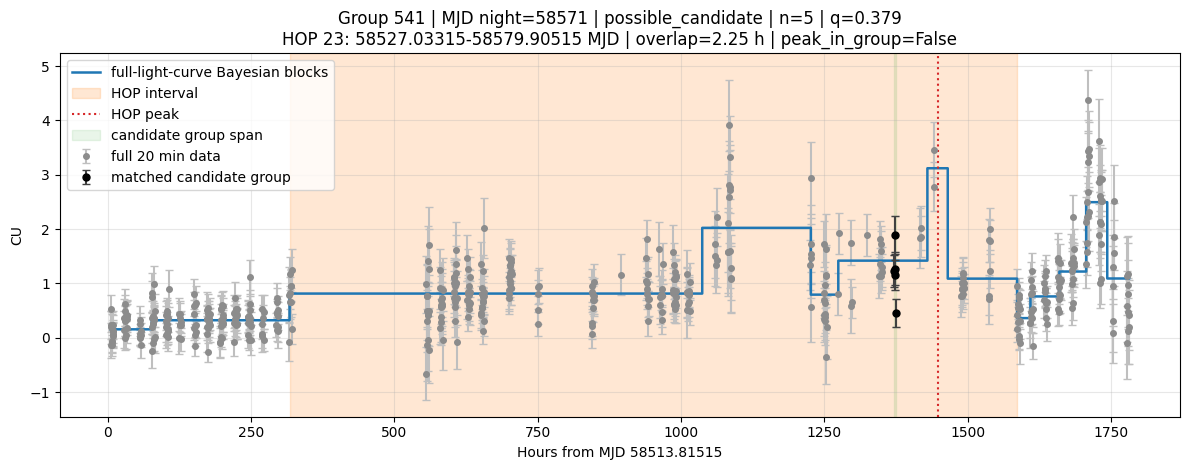

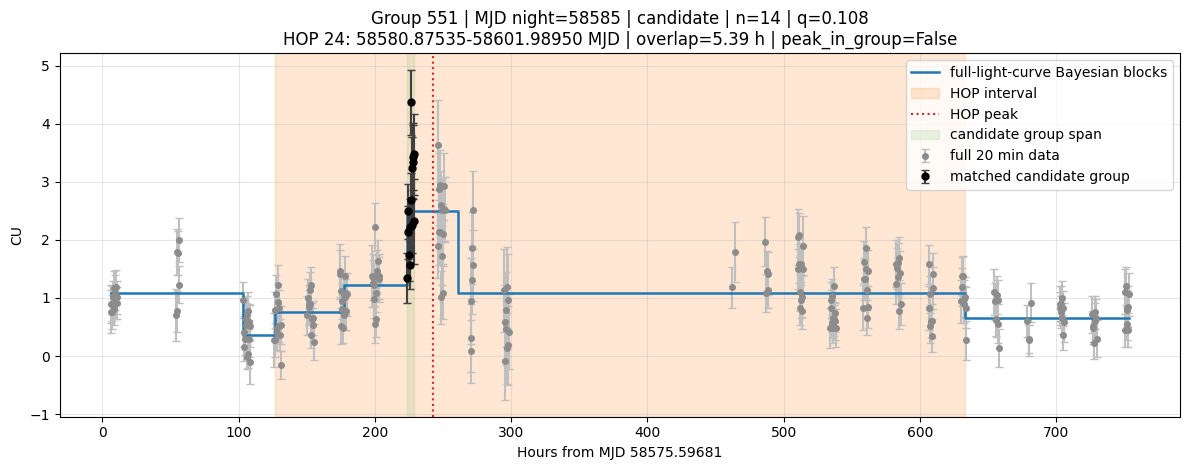

Plotted 15 of 15 matched candidate/HOP overlaps.


In [124]:
# Direct comparison: candidate groups against HOPs from the full 20 min light curve.
# This uses intervals like hops_bl[0].start_time / hops_bl[0].end_time.
full_lc_20, hops_bl_20 = build_full_bblock_lightcurve(
    daten421_20,
    time_col="MJD",
    flux_col="CU",
    err_col="CU_err",
    p0_value=0.05,
    hop_method="baseline",
)

candidate_hop_matches = summarize_candidate_hop_overlaps(
    __daten421_20_mjdnight,
    hops_bl_20,
    classes=("strong_candidate", "candidate", "possible_candidate"),
    min_overlap_hours=0.0,
)
print(
    f"Full light curve: {len(full_lc_20.time)} points, "
    f"{len(full_lc_20.block_val)} Bayesian blocks, {len(hops_bl_20)} baseline HOPs"
)
print(
    f"Matched candidate/HOP overlaps: "
    f"{candidate_hop_matches['hop_index'].notna().sum()}"
)
display(candidate_hop_matches.sort_values(["gruppe", "hop_index"]))

candidate_hop_matches = plot_candidate_hop_overlaps(
    __daten421_20_mjdnight,
    full_lc_20,
    hops_bl_20,
    classes=("strong_candidate", "candidate", "possible_candidate"),
    min_overlap_hours=0.0,
    pad_frac=0.25,
    min_pad_hours=4.0,
    max_plots=None,
)
